# Análisis Exploratorio de Datos (EDA) del Mercado Global de IA

Este notebook realiza un análisis profesional y consultivo del dataset `global_market_ai_dataset.csv`, siguiendo las mejores prácticas de ciencia de datos. El flujo incluye carga, exploración, limpieza, análisis visual, ingeniería de características y recomendaciones para modelado.

## 1. Importación de Librerías y Carga de Datos

En esta sección se importan las librerías esenciales y se carga el dataset. Se realiza una inspección preliminar para entender la estructura básica de los datos.

In [3]:
# Importación de librerías esenciales para análisis de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos para gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette('deep')

# Carga del dataset
dataset_path = 'student_mental_health_burnout.csv'
try:
    df = pd.read_csv(dataset_path)
    print(f"Dataset cargado correctamente. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
except Exception as e:
    print(f"Error al cargar el dataset: {e}")
    df = pd.DataFrame()  # DataFrame vacío para evitar errores posteriores

# Vista preliminar de los datos
display(df.head())
print("\nInformación general del DataFrame:")
df.info()

Dataset cargado correctamente. Filas: 150000, Columnas: 20


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low



Información general del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  str    
 3   course                   150000 non-null  str    
 4   year                     150000 non-null  str    
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  str    
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 no

## 2. Exploración Inicial de Datos

En esta sección se analiza la estructura y calidad de los datos:
- Conteo de valores nulos
- Estadísticas descriptivas para variables numéricas y categóricas
- Distribución y cardinalidad de variables

In [4]:
# Conteo de valores nulos por columna
def null_summary(dataframe):
    nulls = dataframe.isnull().sum()
    percent = 100 * nulls / len(dataframe)
    summary = pd.DataFrame({'Nulos': nulls, '% Nulos': percent})
    return summary[summary['Nulos'] > 0].sort_values(by='Nulos', ascending=False)

print('Valores nulos por columna:')
display(null_summary(df))

# Estadísticas descriptivas para variables numéricas
print('\nEstadísticas descriptivas (numéricas):')
display(df.describe().T)

# Estadísticas descriptivas para variables categóricas
def describe_categoricals(dataframe):
    cat_cols = dataframe.select_dtypes(include=['object', 'category']).columns
    return dataframe[cat_cols].describe().T

print('\nEstadísticas descriptivas (categóricas):')
display(describe_categoricals(df))

Valores nulos por columna:


,Nulos,% Nulos



Estadísticas descriptivas (numéricas):


,count,mean,std,min,25%,50%,75%,max
student_id,150000.0,175000.500000,43301.414527,100001.0,137500.75,175000.50,212500.25,250000.0
age,150000.0,21.000380,2.581216,17.0,19.00,21.00,23.00,25.0
daily_study_hours,150000.0,5.507869,2.595592,1.0,3.30,5.50,7.70,10.0
daily_sleep_hours,150000.0,6.499361,1.443859,4.0,5.20,6.50,7.70,9.0
screen_time_hours,150000.0,6.502819,3.178948,1.0,3.70,6.50,9.30,12.0
anxiety_score,150000.0,5.493907,2.872607,1.0,3.00,5.00,8.00,10.0
depression_score,150000.0,5.497360,2.869022,1.0,3.00,5.00,8.00,10.0
academic_pressure_score,150000.0,5.507427,2.875524,1.0,3.00,6.00,8.00,10.0
financial_stress_score,150000.0,5.496027,2.864698,1.0,3.00,6.00,8.00,10.0
social_support_score,150000.0,5.516060,2.870493,1.0,3.00,6.00,8.00,10.0



Estadísticas descriptivas (categóricas):


C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\2209069975.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = dataframe.select_dtypes(include=['object', 'category']).columns


,count,unique,top,freq
gender,150000,3,Other,50048
course,150000,6,MBA,25231
year,150000,4,1st,37680
stress_level,150000,3,High,50295
sleep_quality,150000,3,Good,50143
internet_quality,150000,3,Average,50138
burnout_level,150000,3,Low,50265


## 3. Limpieza y Preprocesamiento de Datos

En esta sección se abordan los problemas de calidad de datos:
- Tratamiento de valores nulos (imputación o eliminación, según el caso)
- Eliminación de duplicados
- Corrección de tipos de datos
- Detección y manejo de outliers

In [5]:
# --- Tratamiento de valores nulos ---
# Supuesto: Si una columna tiene >40% nulos, se elimina. Si no, se imputa (media numérica, moda categórica)
nulls = df.isnull().mean()
cols_drop = nulls[nulls > 0.4].index.tolist()
if cols_drop:
    print(f"Columnas eliminadas por alto porcentaje de nulos (>40%): {cols_drop}")
    df.drop(columns=cols_drop, inplace=True)
else:
    print("No se eliminaron columnas por nulos excesivos.")

for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in [np.float64, np.int64]:
            impute_value = df[col].mean()
            df[col].fillna(impute_value, inplace=True)
            print(f"Nulos en '{col}' imputados con la media: {impute_value:.2f}")
        else:
            impute_value = df[col].mode()[0]
            df[col].fillna(impute_value, inplace=True)
            print(f"Nulos en '{col}' imputados con la moda: {impute_value}")

# --- Eliminación de duplicados ---
dup_count = df.duplicated().sum()
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"{dup_count} filas duplicadas eliminadas.")
else:
    print("No se encontraron filas duplicadas.")

# --- Corrección de tipos de datos ---
# Supuesto: Convertir columnas tipo fecha si existen
for col in df.columns:
    if 'date' in col.lower() or 'fecha' in col.lower():
        try:
            df[col] = pd.to_datetime(df[col])
            print(f"Columna '{col}' convertida a datetime.")
        except Exception as e:
            print(f"No se pudo convertir '{col}' a datetime: {e}")

# --- Detección y manejo de outliers (IQR) ---
def remove_outliers_iqr(dataframe, factor=1.5):
    num_cols = dataframe.select_dtypes(include=[np.number]).columns
    outlier_indices = set()
    for col in num_cols:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        outliers = dataframe[(dataframe[col] < lower) | (dataframe[col] > upper)].index
        outlier_indices.update(outliers)
    print(f"Filas eliminadas por outliers (IQR): {len(outlier_indices)}")
    return dataframe.drop(index=outlier_indices)

df = remove_outliers_iqr(df)

display(df.head())

No se eliminaron columnas por nulos excesivos.
No se encontraron filas duplicadas.
Filas eliminadas por outliers (IQR): 0


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


## 4. Análisis Exploratorio de Datos (EDA)

Visualizaciones y análisis para descubrir patrones, relaciones e insights clave:
- Histogramas y gráficos de densidad
- Boxplots por categorías
- Mapa de calor de correlación

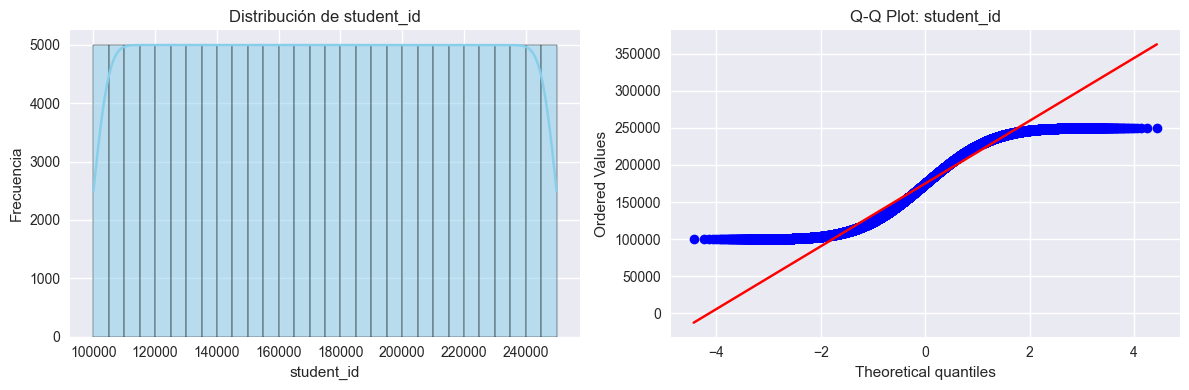

  student_id: Shapiro-Wilk p=0.0000 → ✗ Not normal


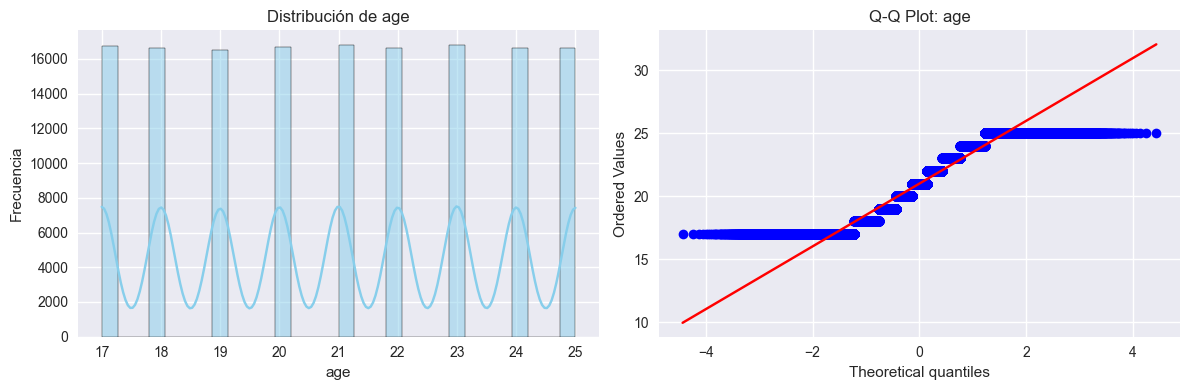

  age: Shapiro-Wilk p=0.0000 → ✗ Not normal


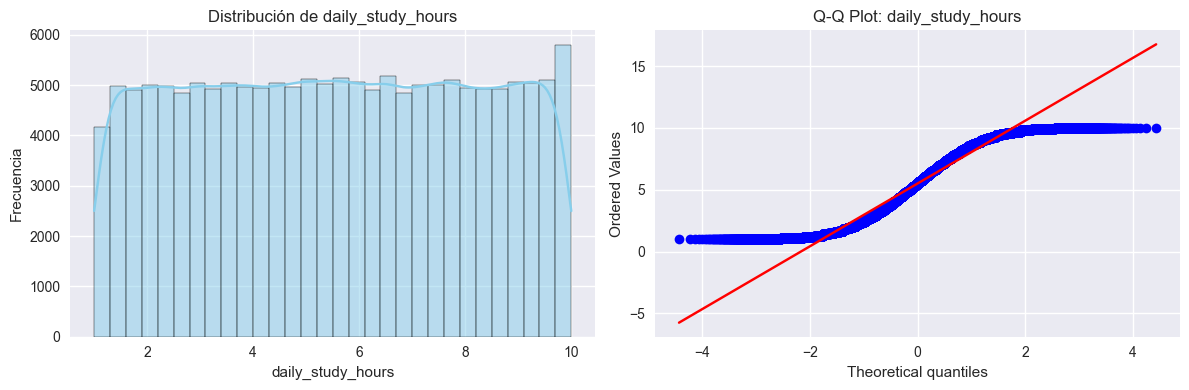

  daily_study_hours: Shapiro-Wilk p=0.0000 → ✗ Not normal


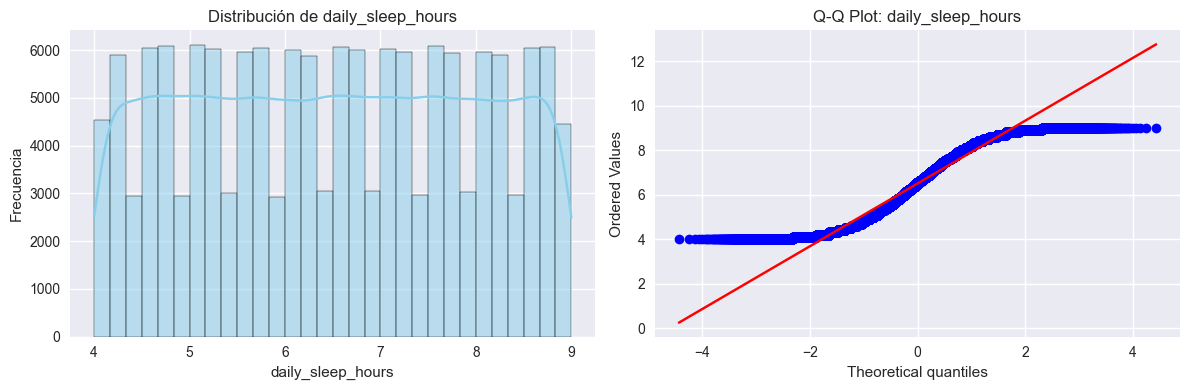

  daily_sleep_hours: Shapiro-Wilk p=0.0000 → ✗ Not normal


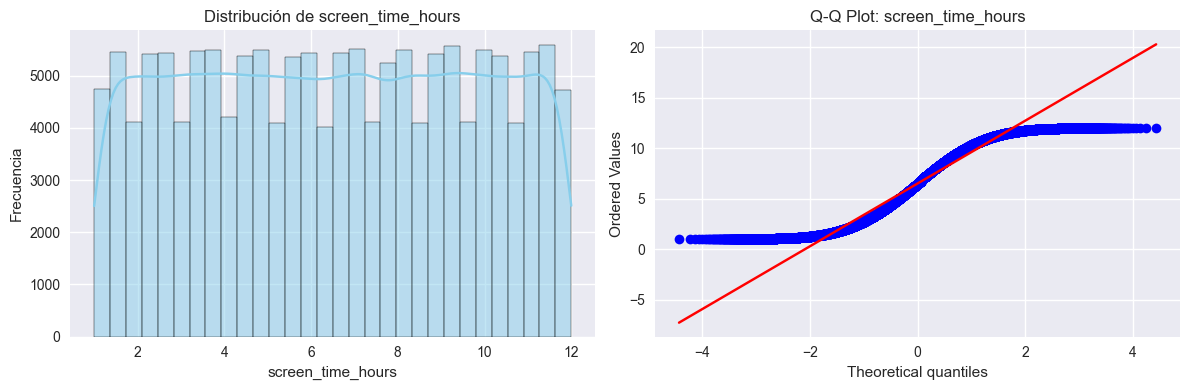

  screen_time_hours: Shapiro-Wilk p=0.0000 → ✗ Not normal


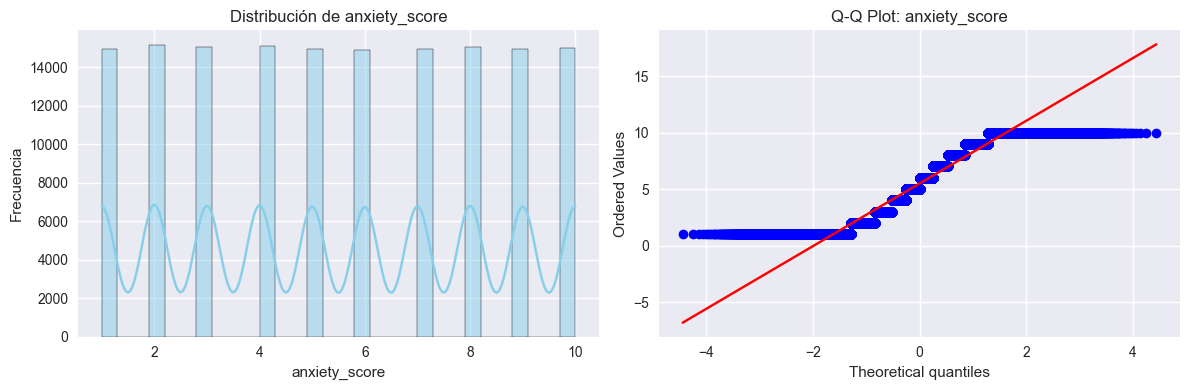

  anxiety_score: Shapiro-Wilk p=0.0000 → ✗ Not normal


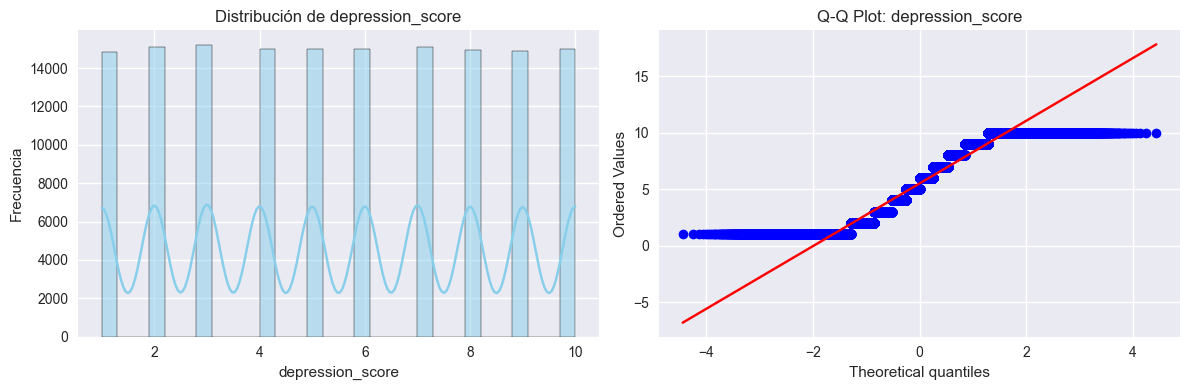

  depression_score: Shapiro-Wilk p=0.0000 → ✗ Not normal


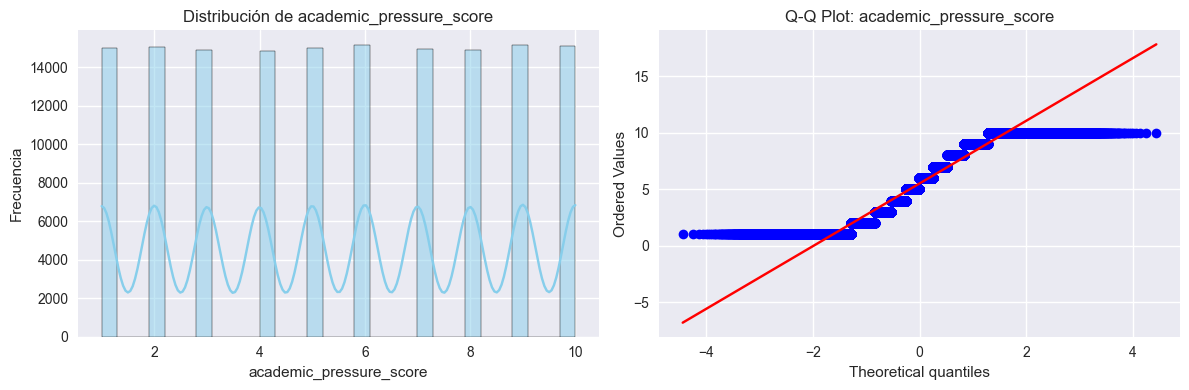

  academic_pressure_score: Shapiro-Wilk p=0.0000 → ✗ Not normal


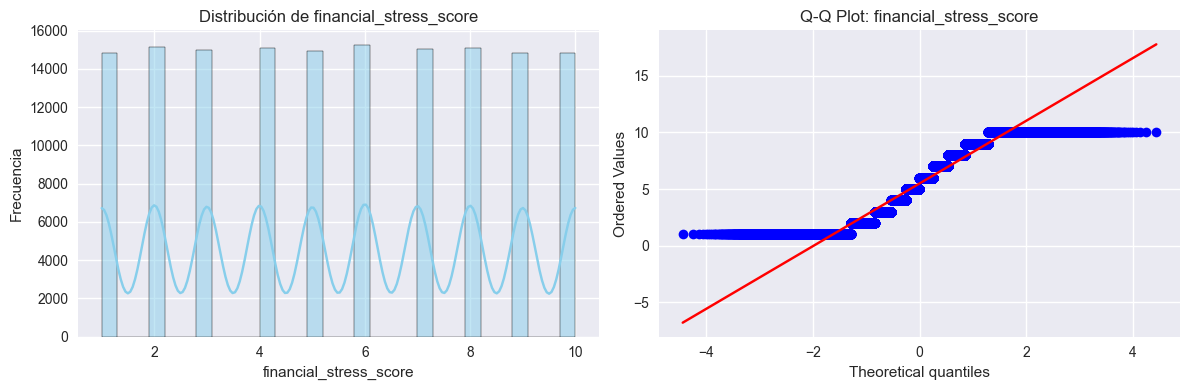

  financial_stress_score: Shapiro-Wilk p=0.0000 → ✗ Not normal


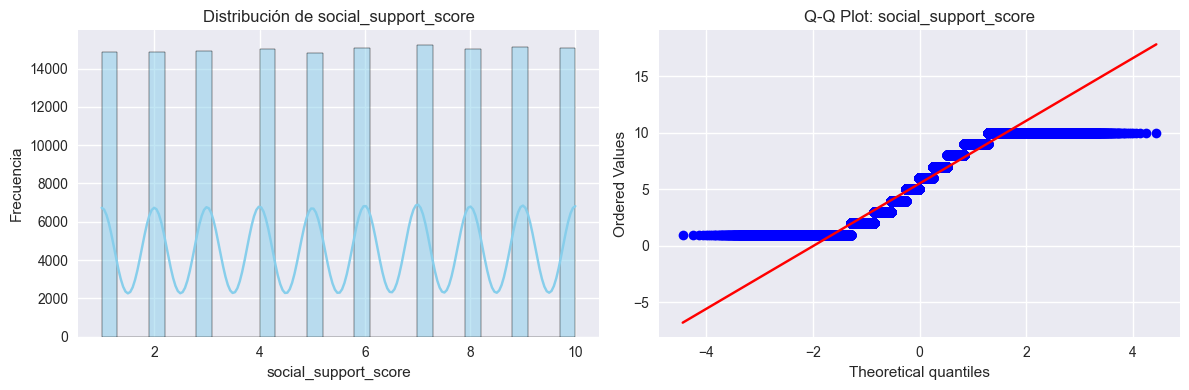

  social_support_score: Shapiro-Wilk p=0.0000 → ✗ Not normal


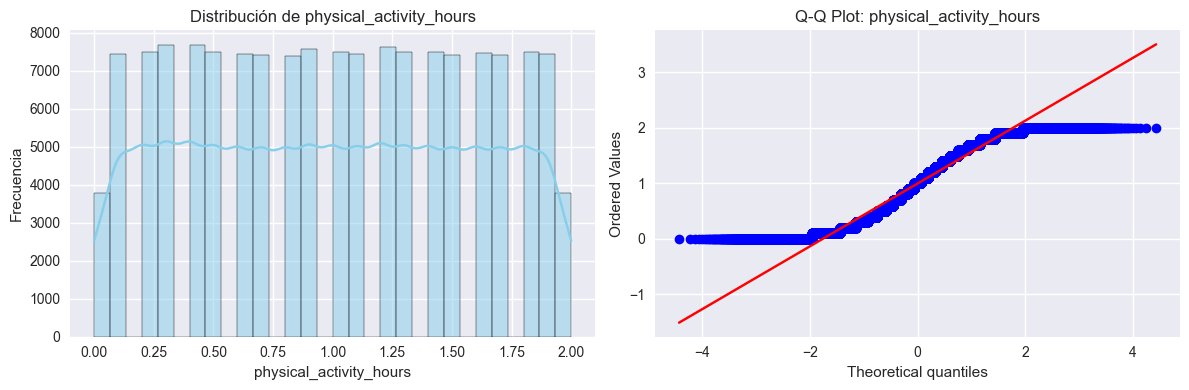

  physical_activity_hours: Shapiro-Wilk p=0.0000 → ✗ Not normal


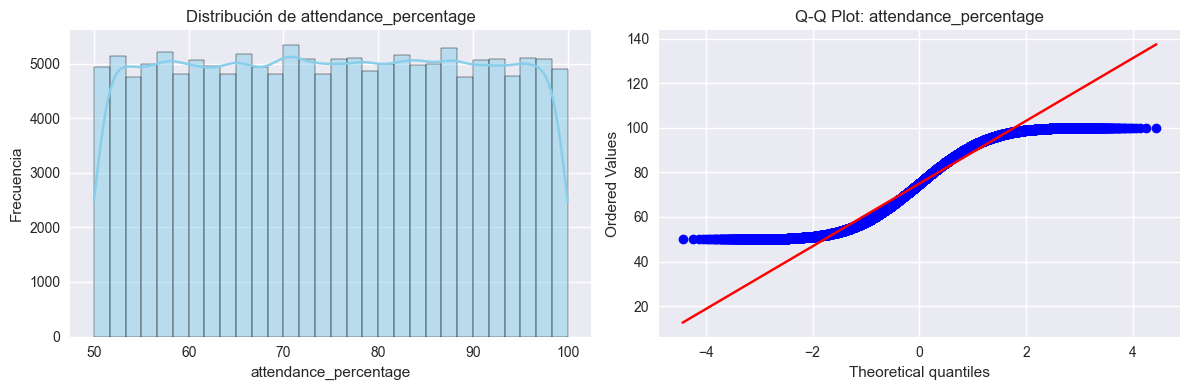

  attendance_percentage: Shapiro-Wilk p=0.0000 → ✗ Not normal


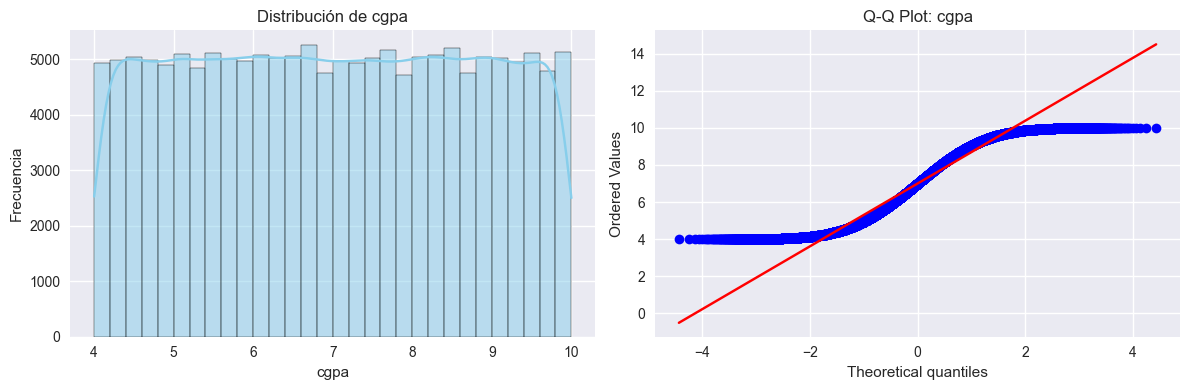

  cgpa: Shapiro-Wilk p=0.0000 → ✗ Not normal


C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns
C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


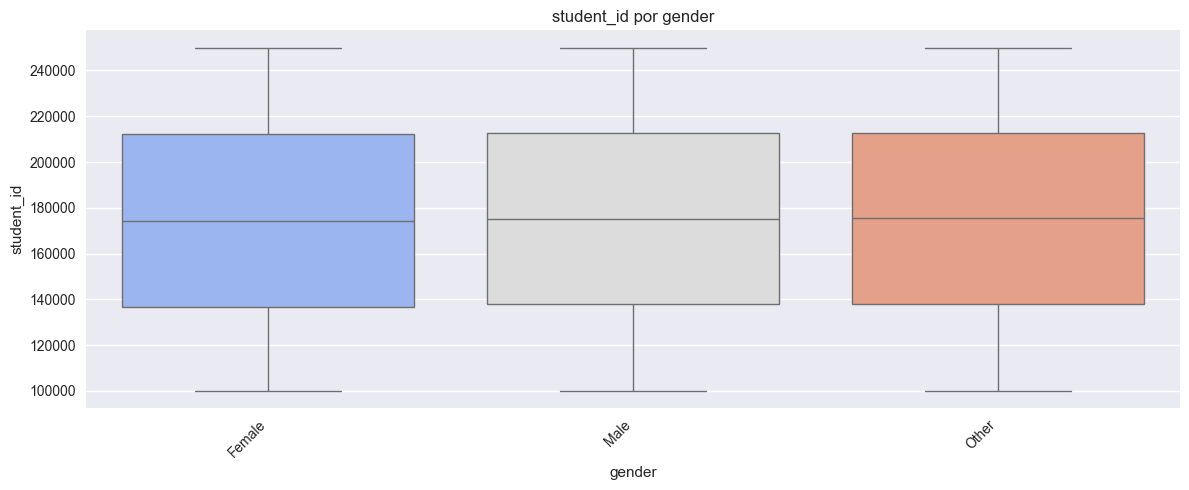

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


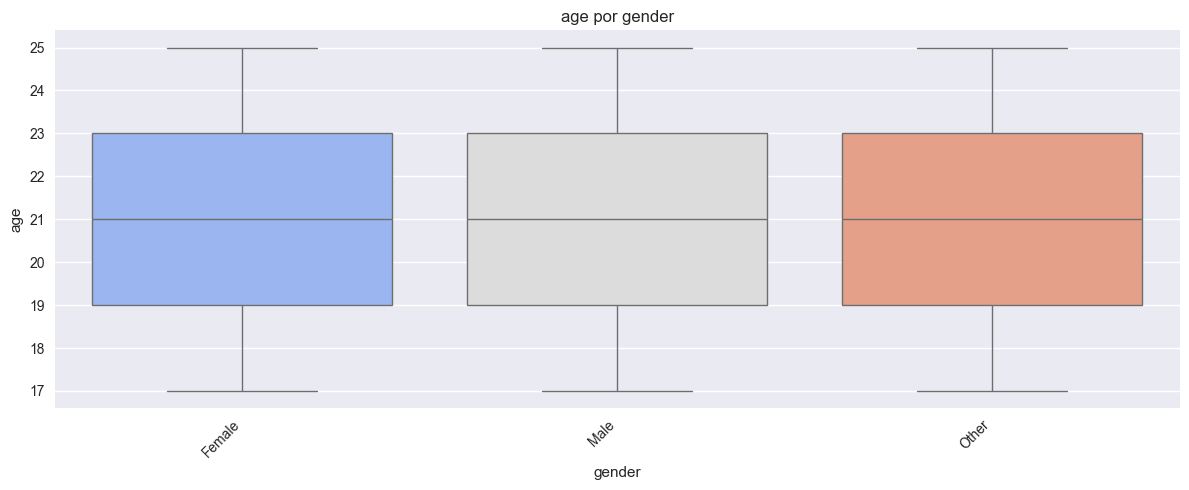

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


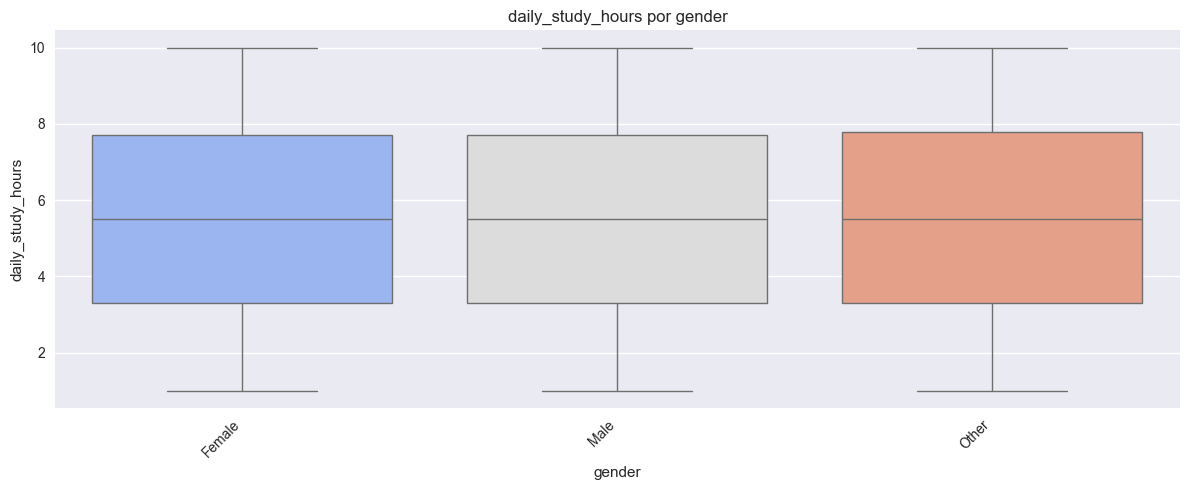

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


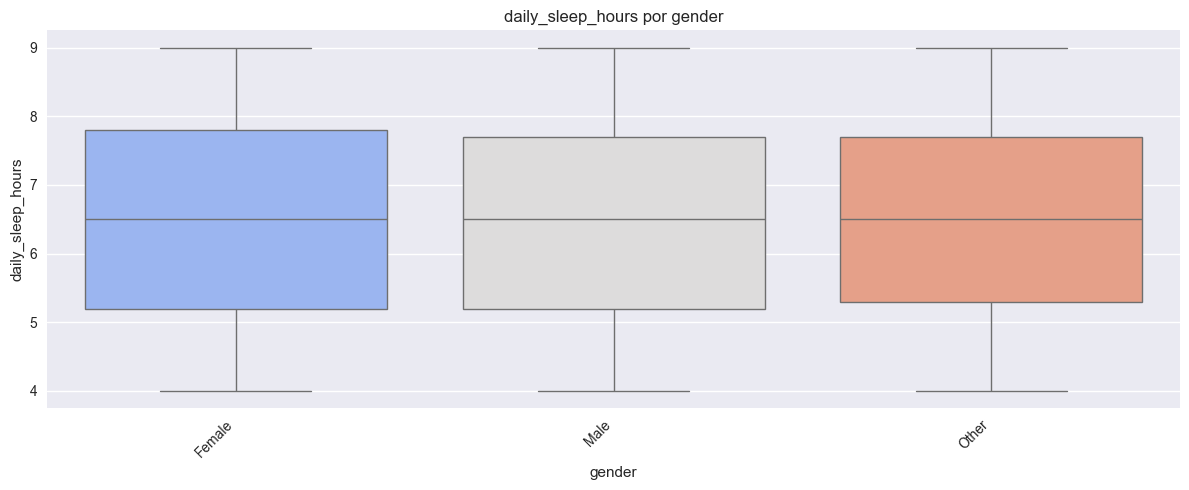

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


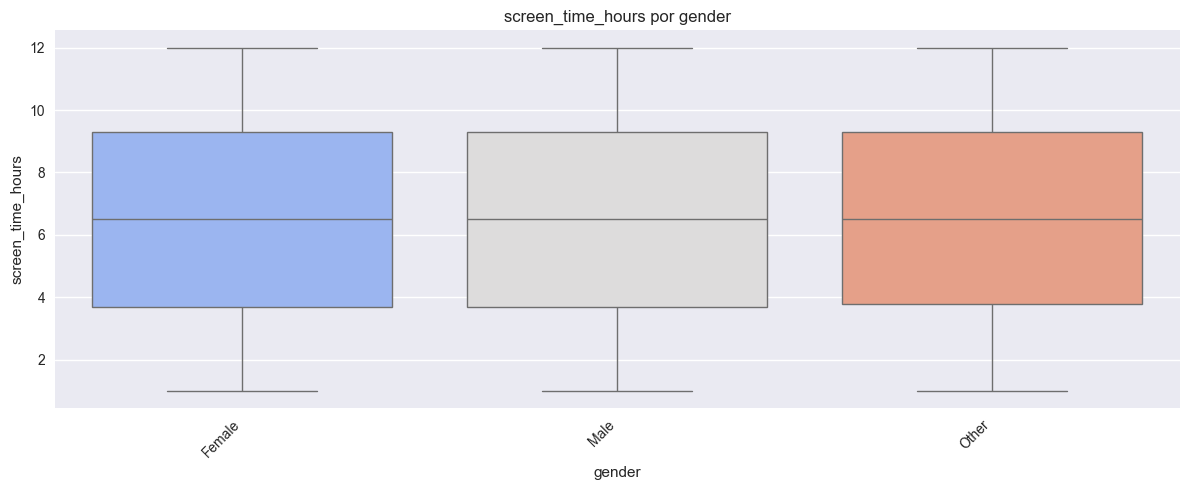

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


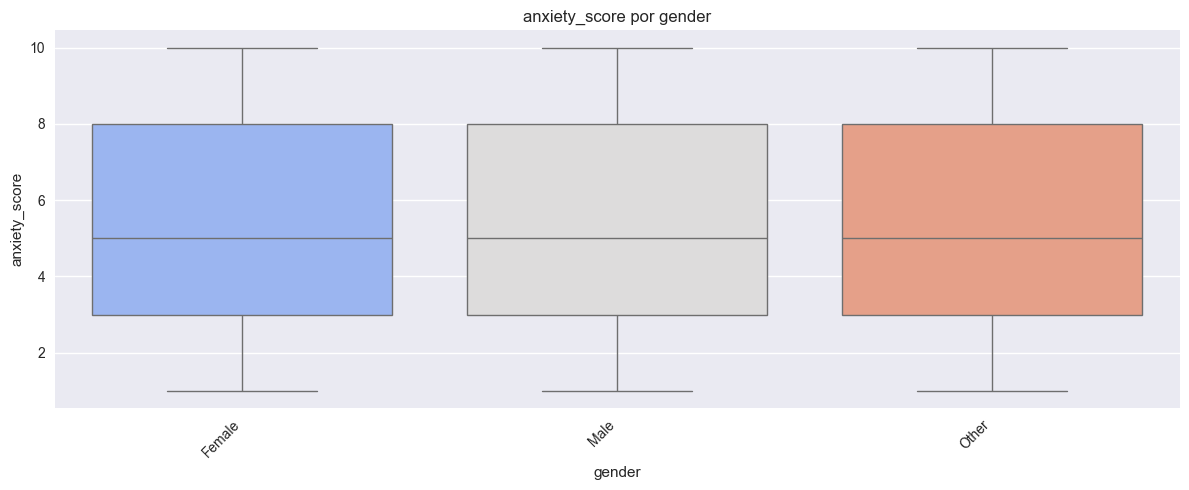

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


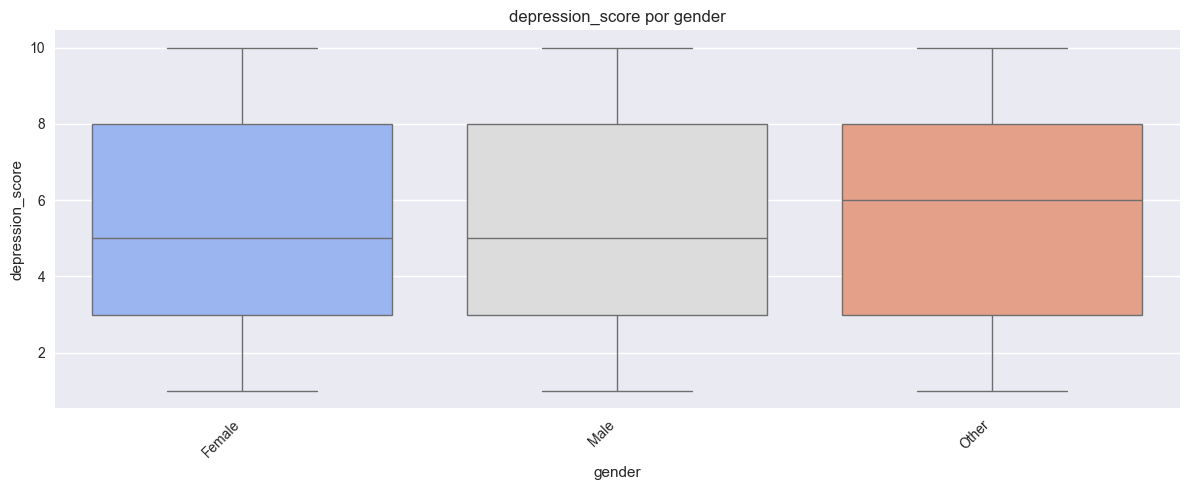

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


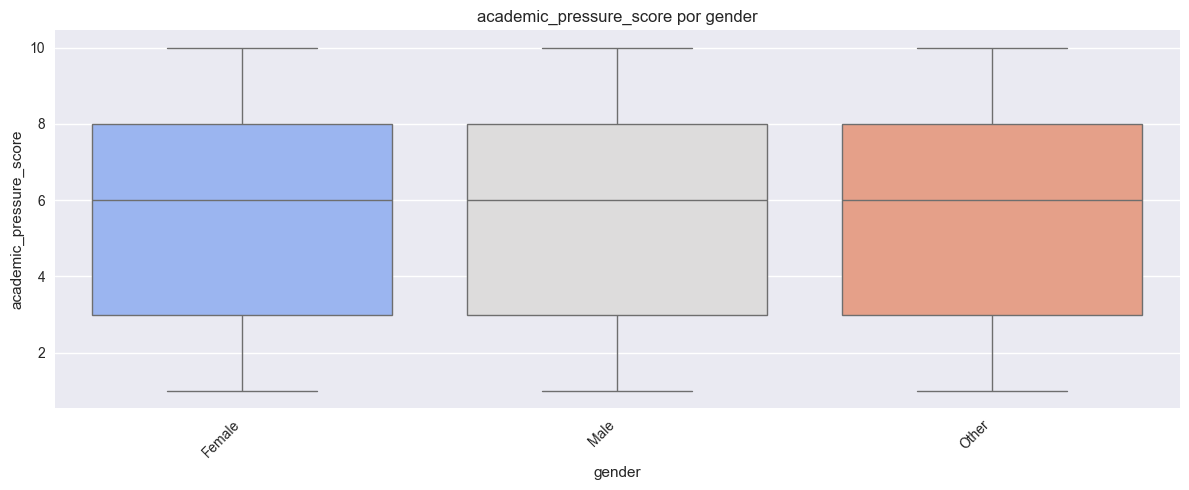

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


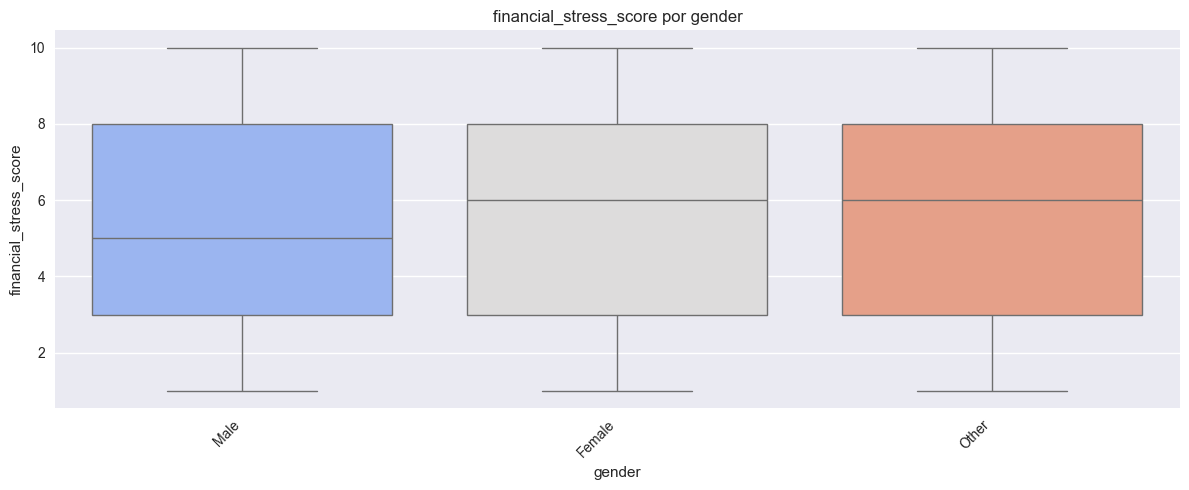

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


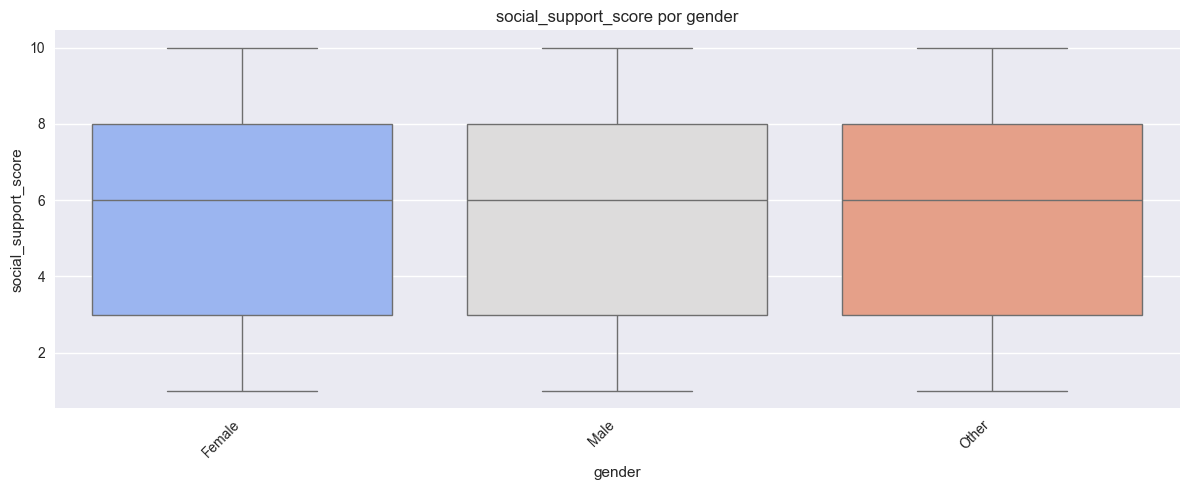

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


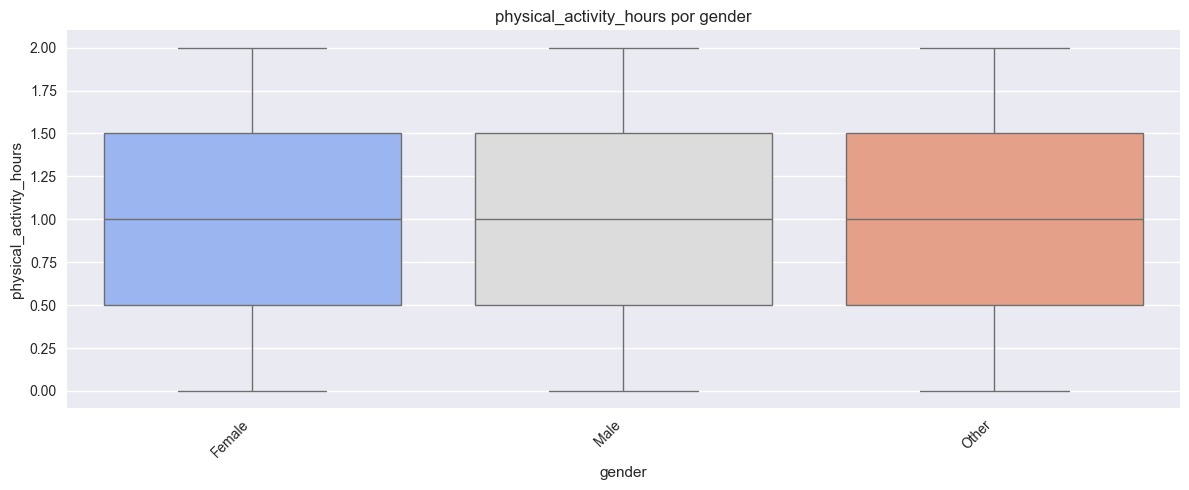

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


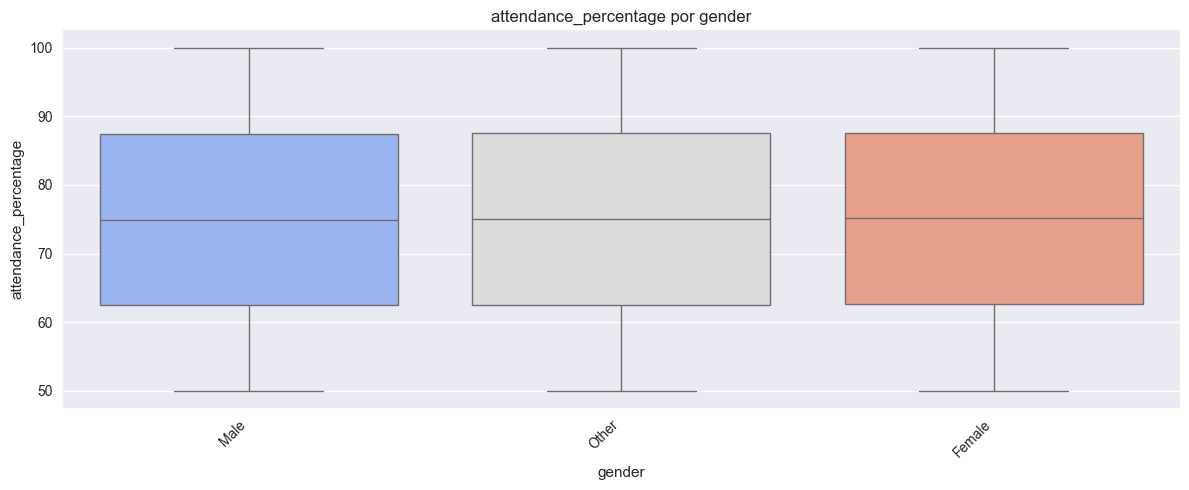

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


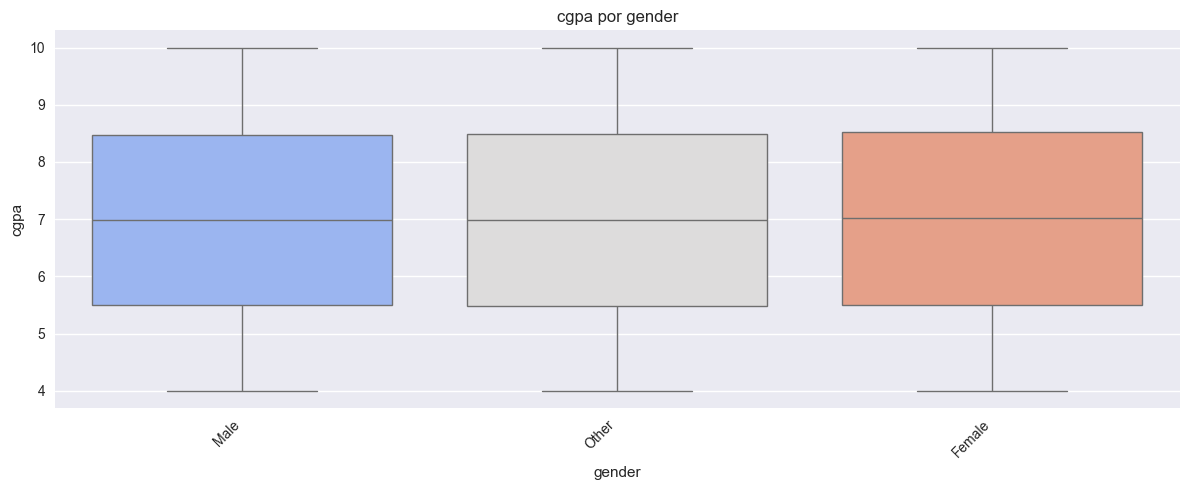

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


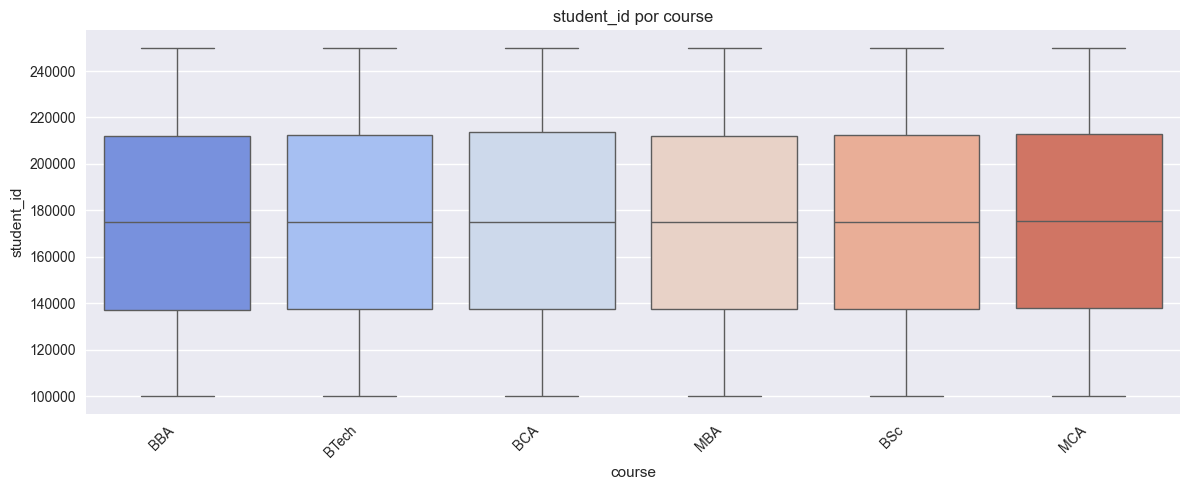

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


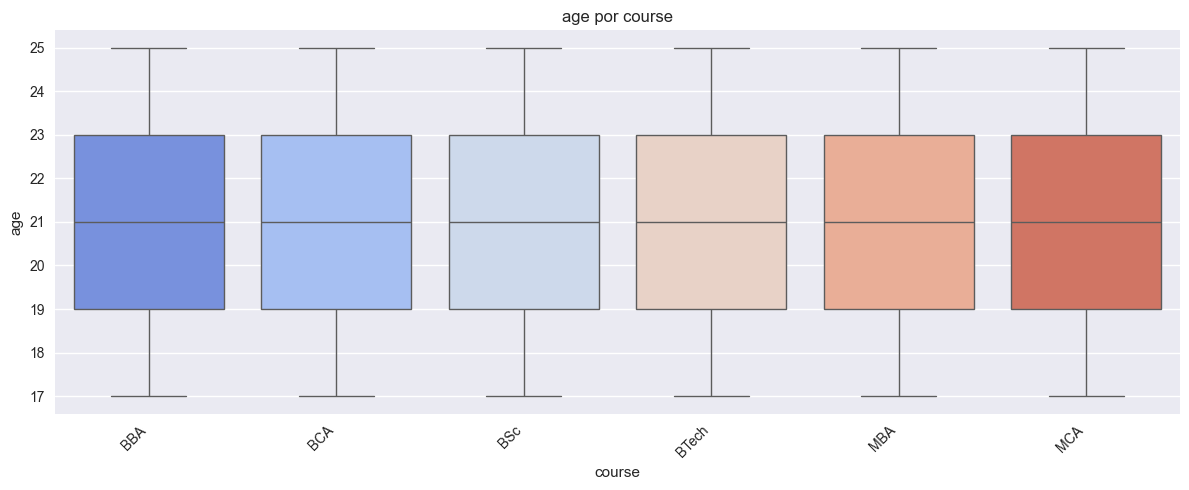

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


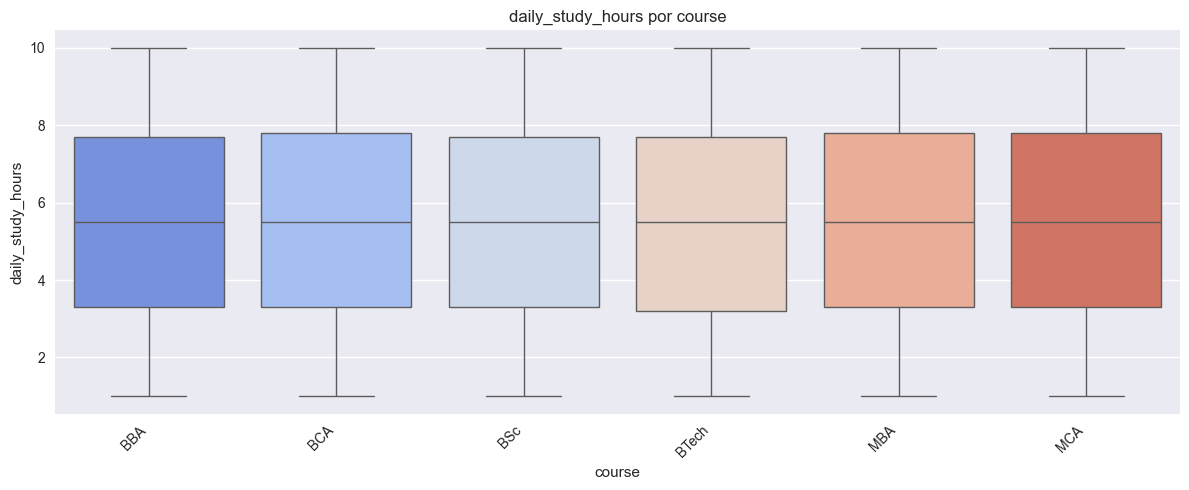

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


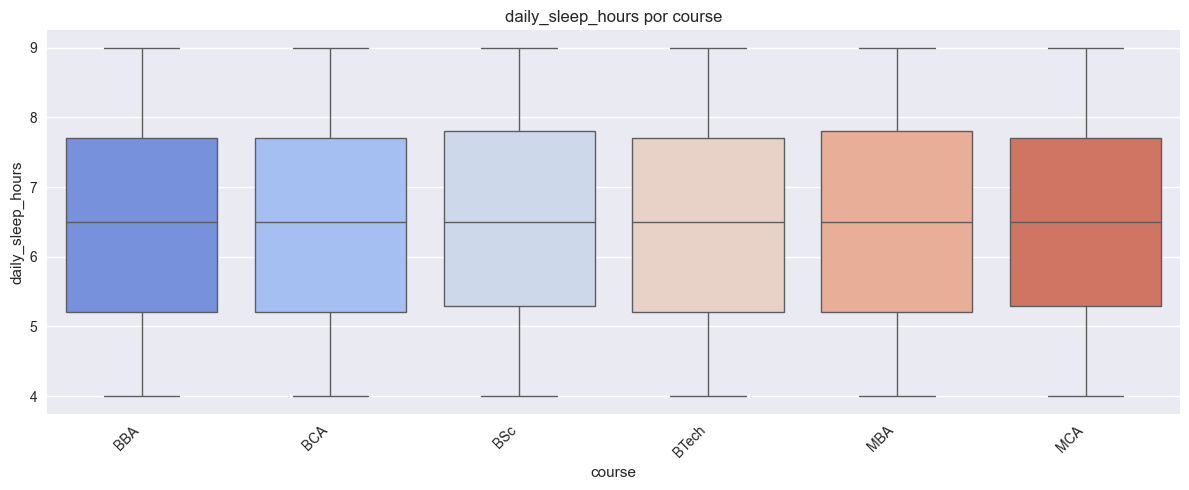

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


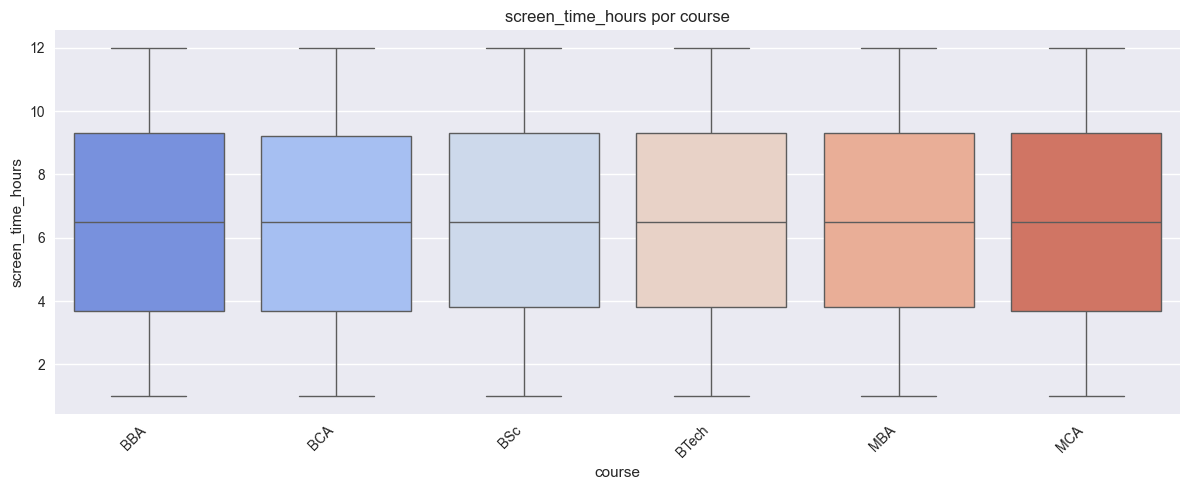

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


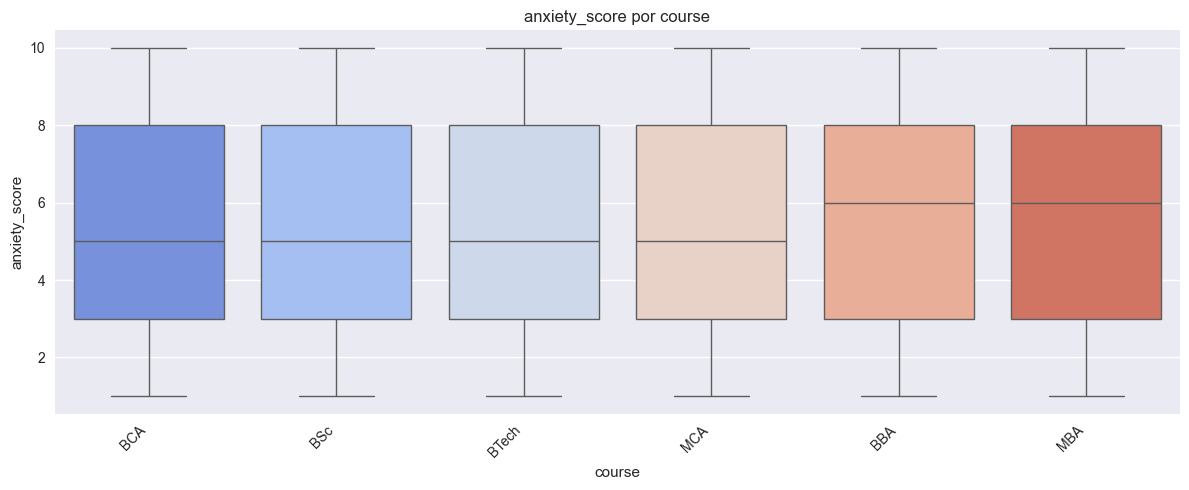

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


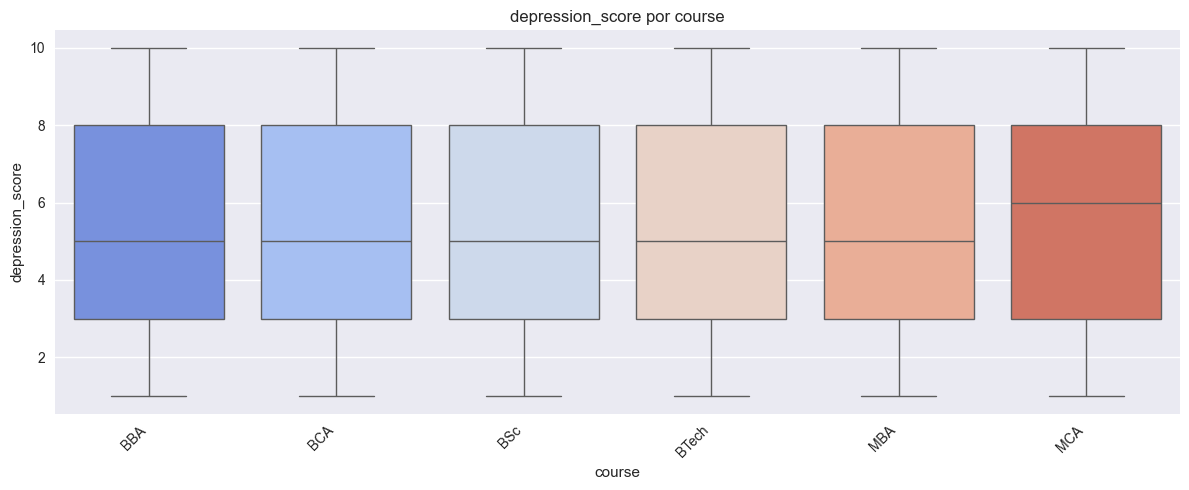

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


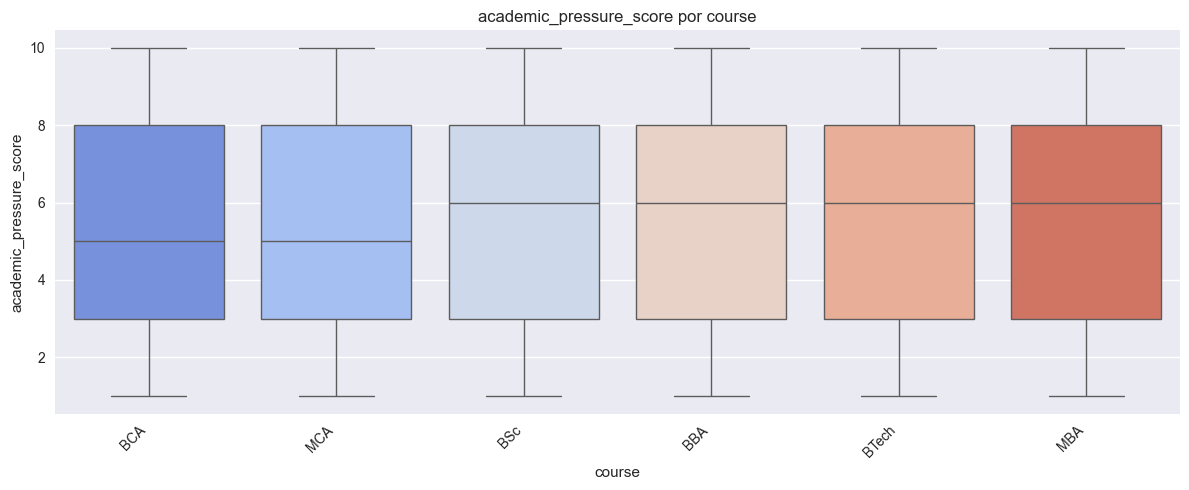

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


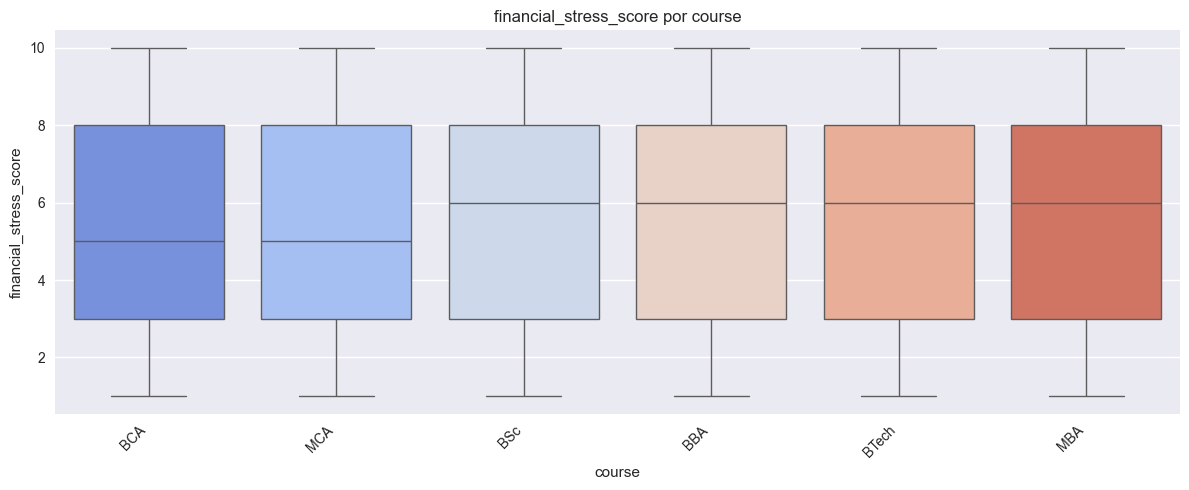

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


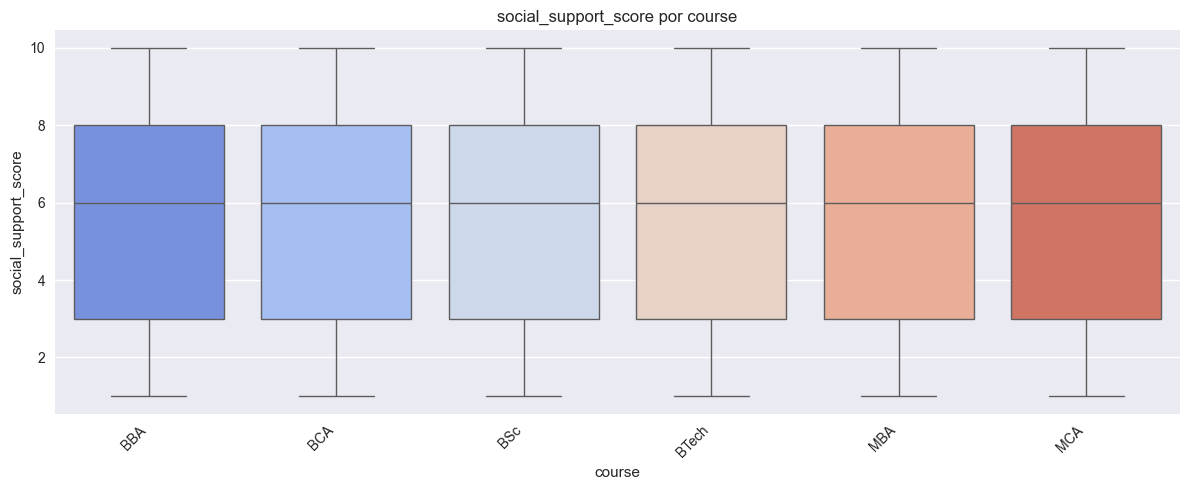

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


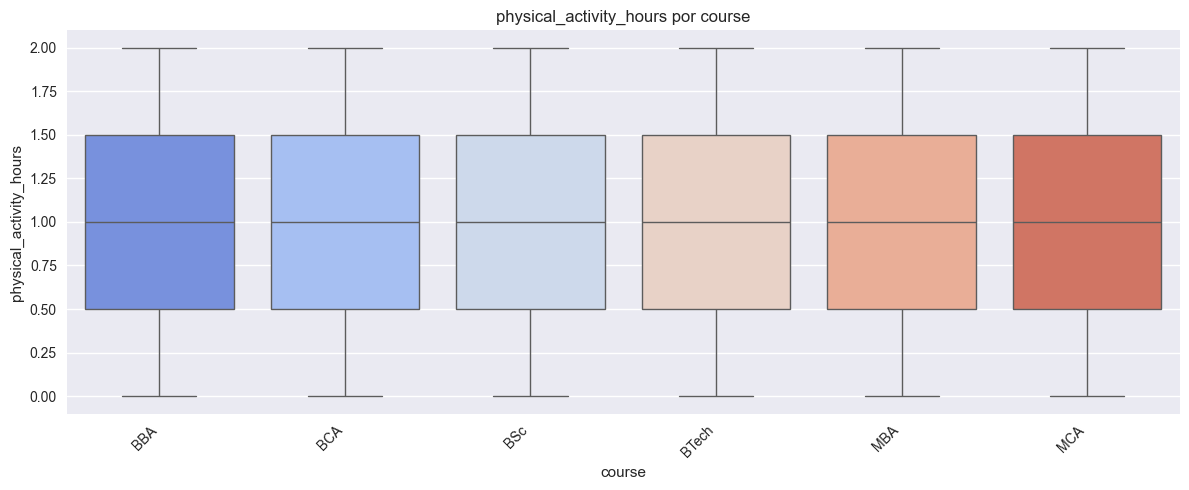

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


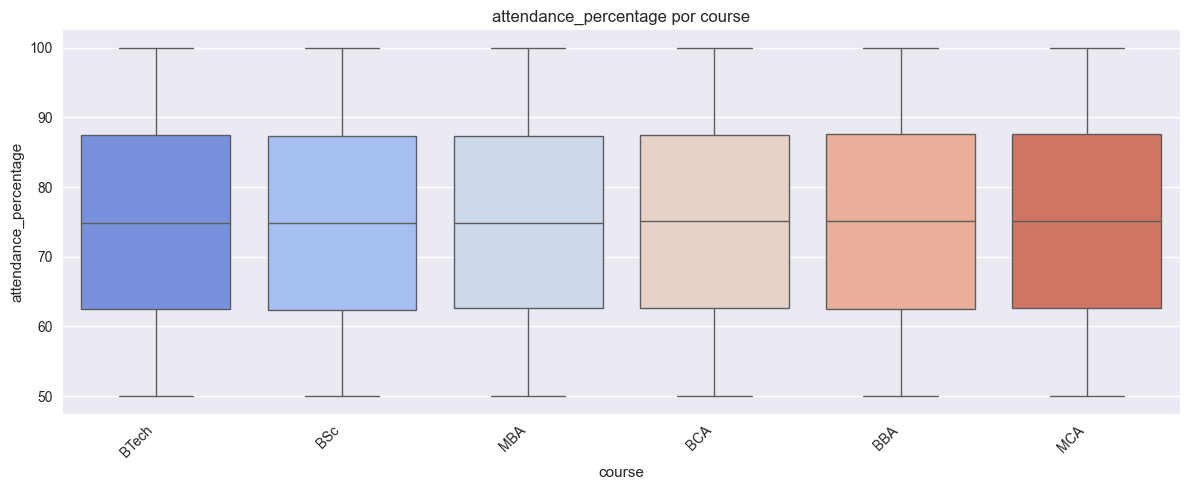

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


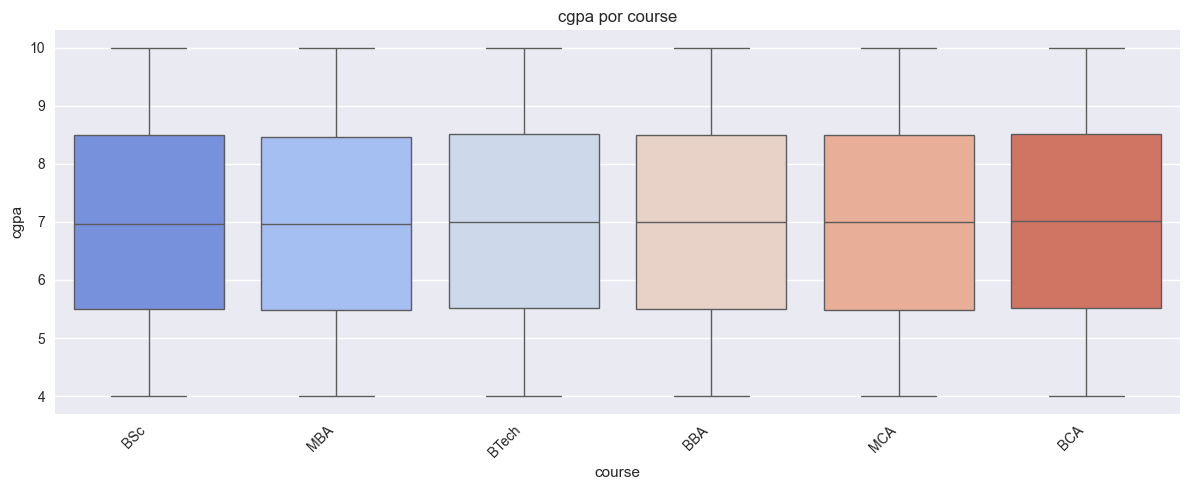

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


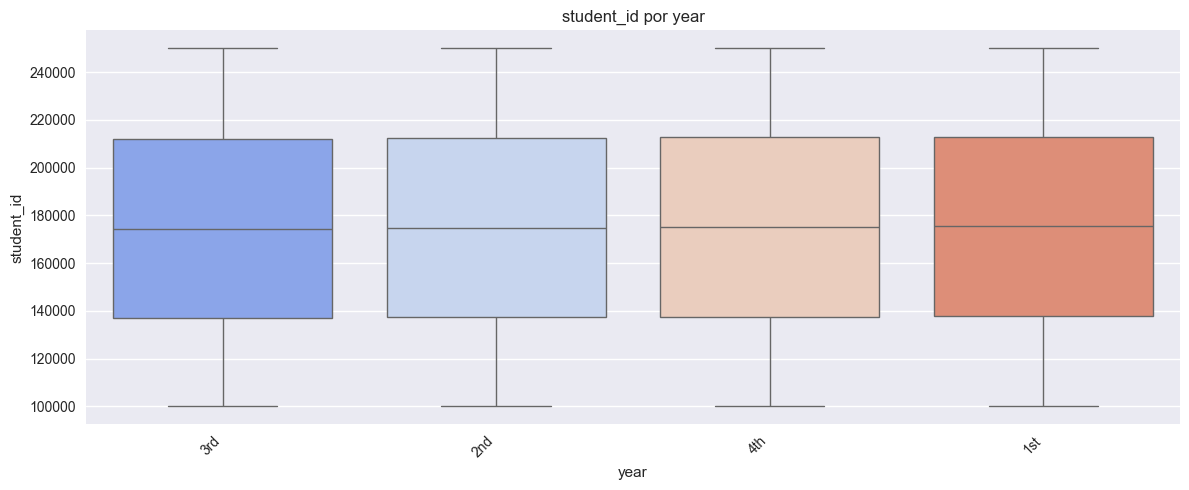

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


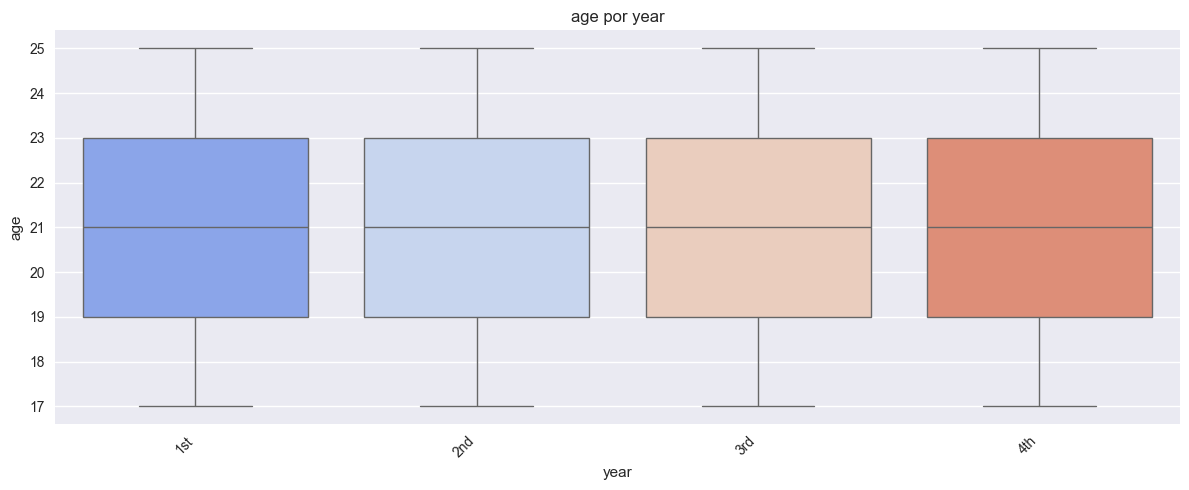

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


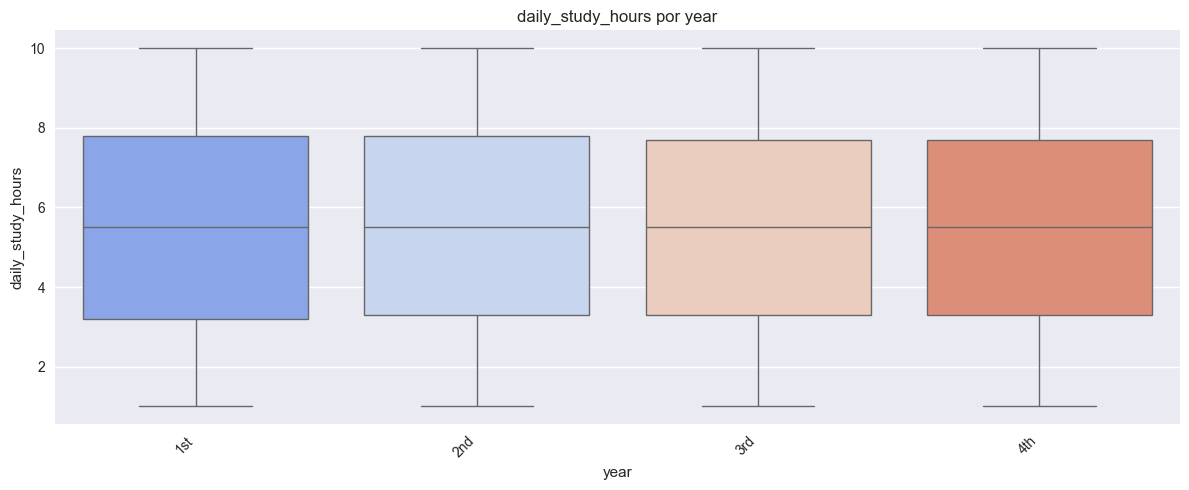

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


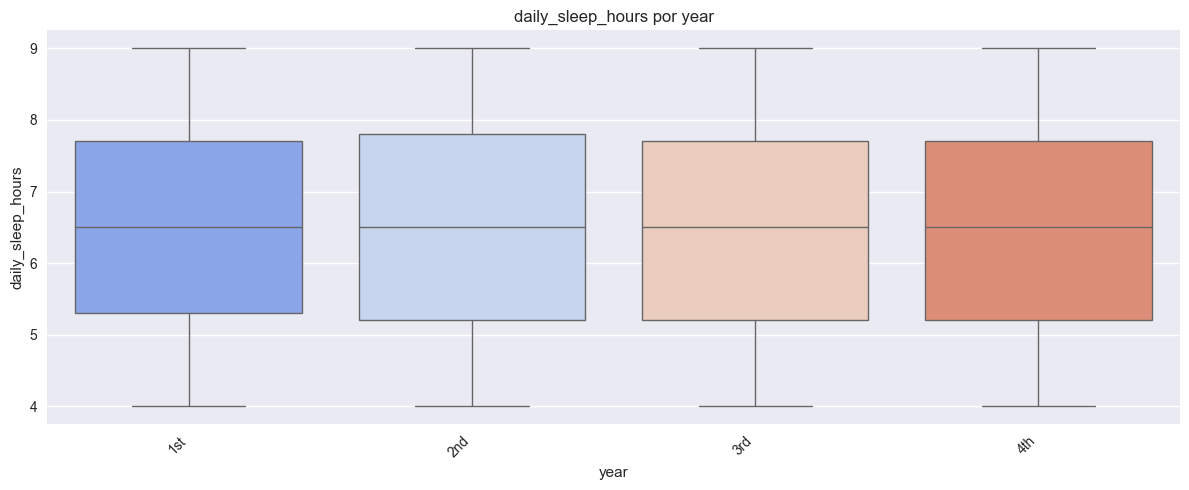

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


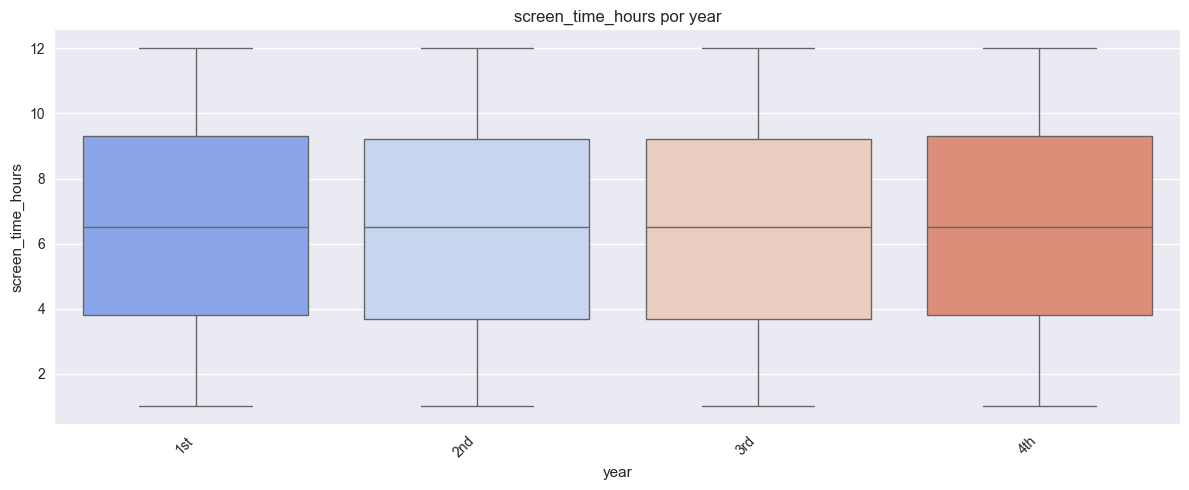

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


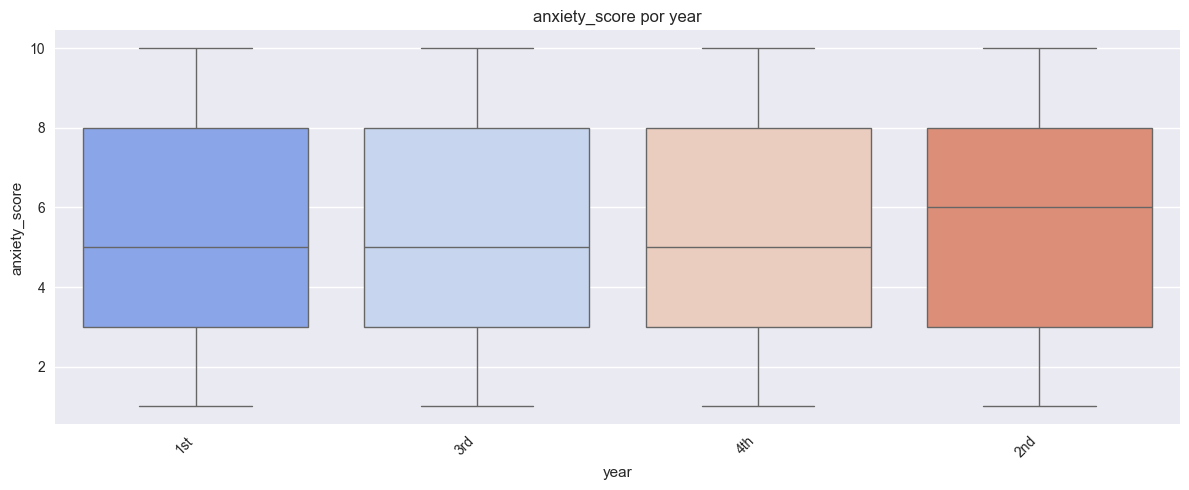

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


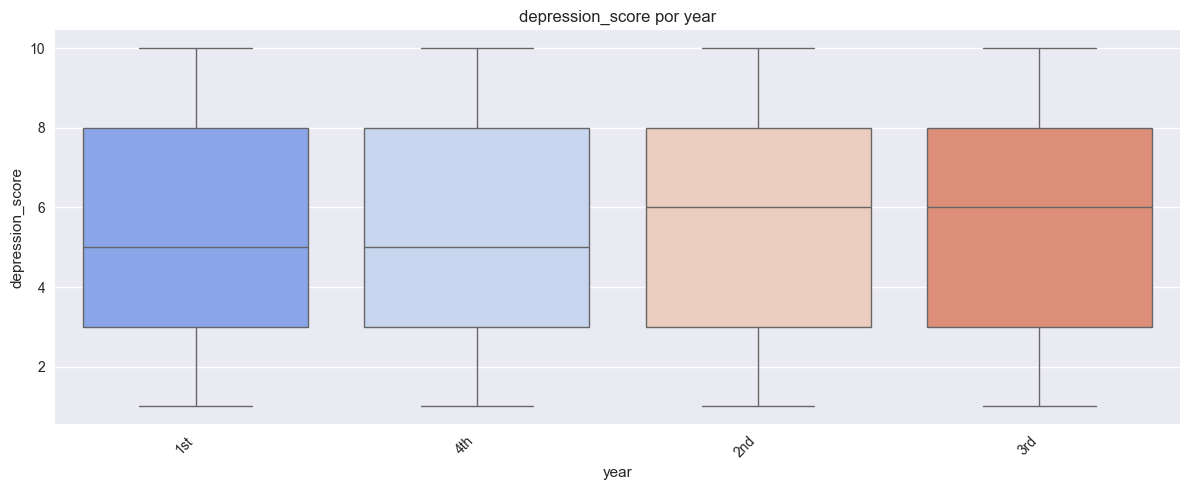

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


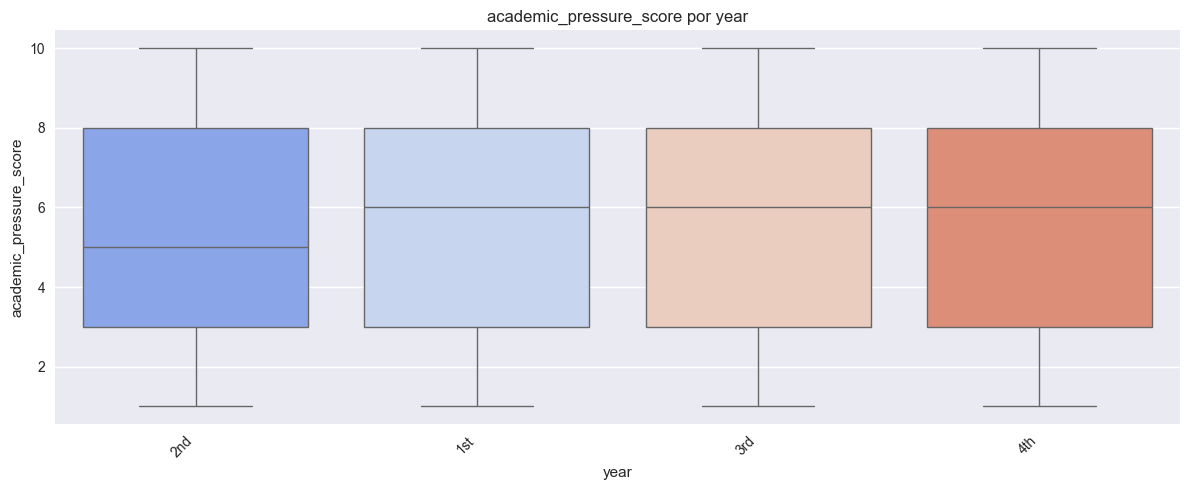

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


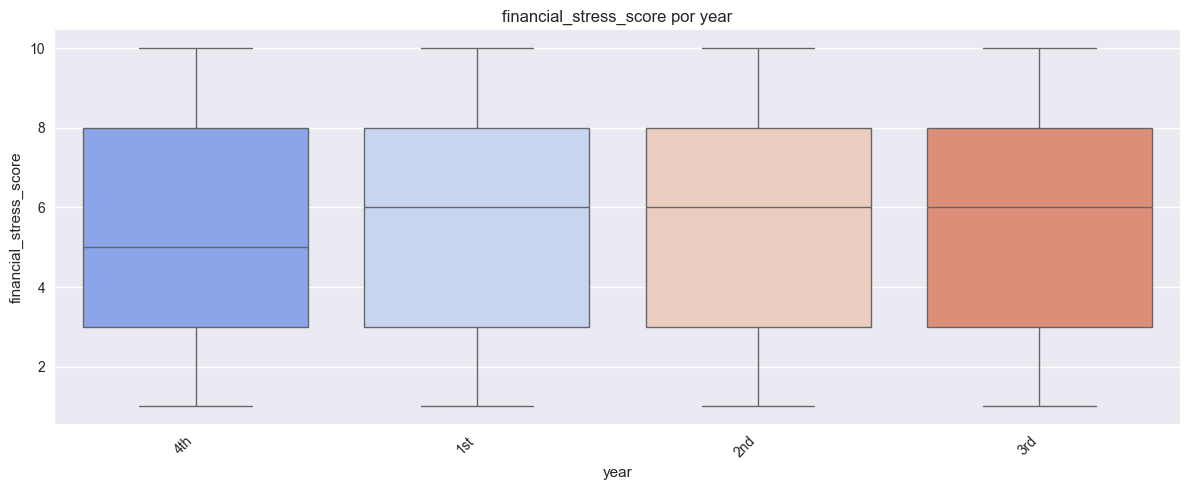

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


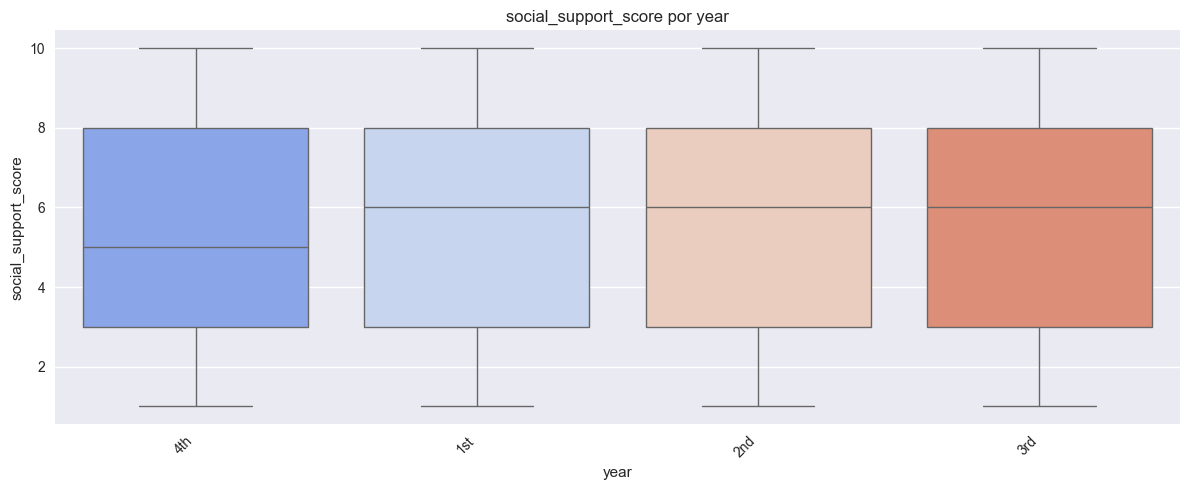

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


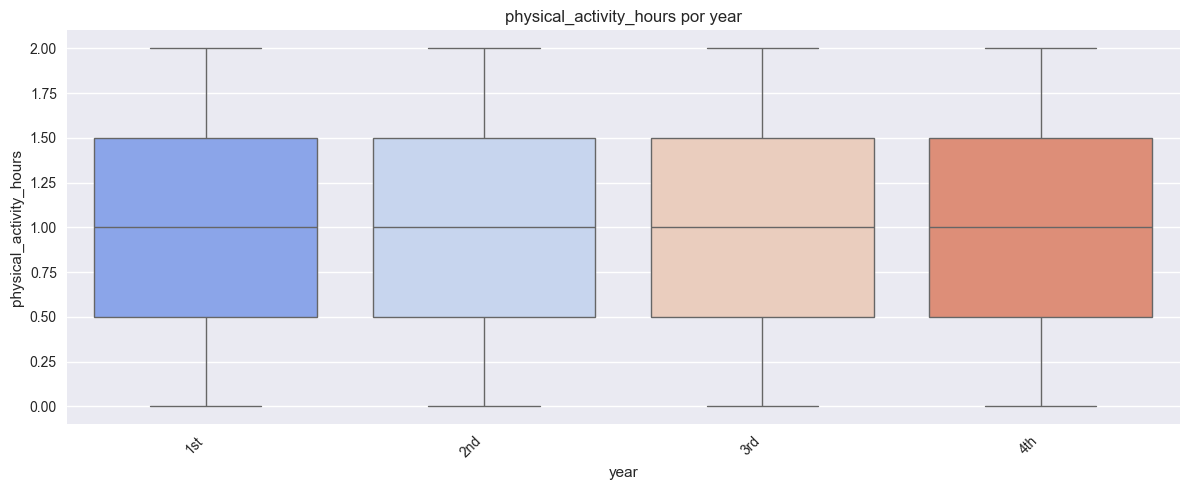

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


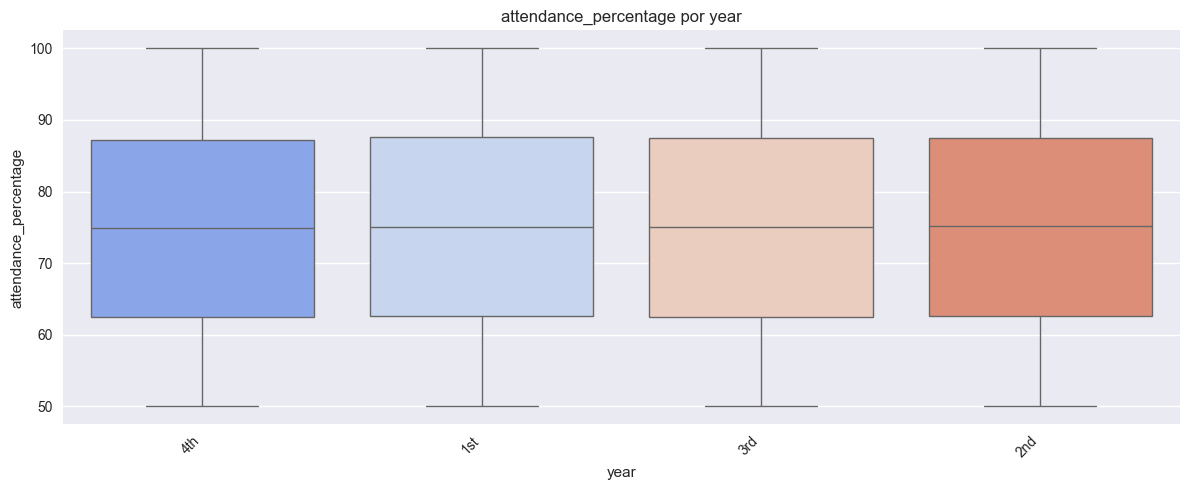

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


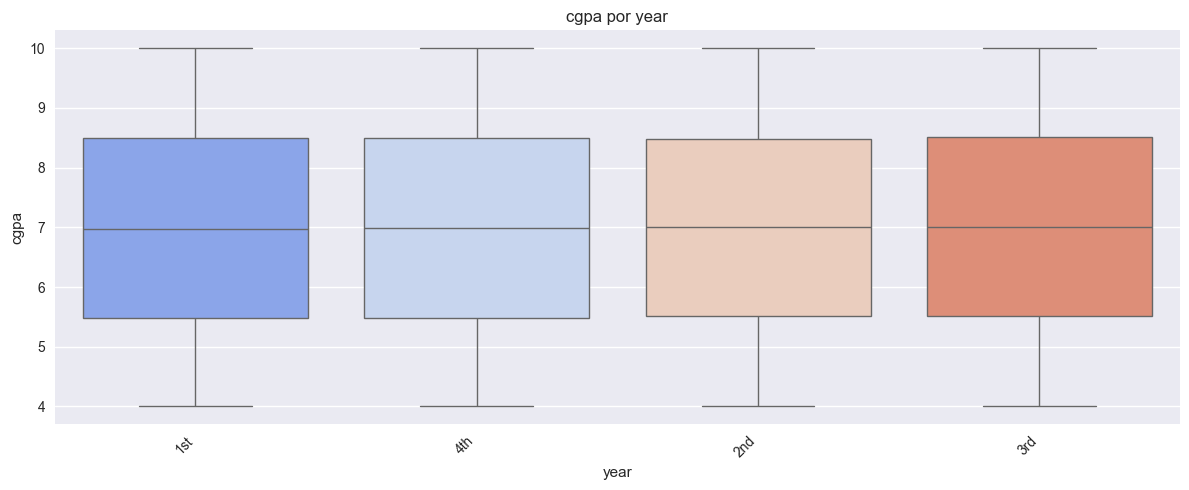

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


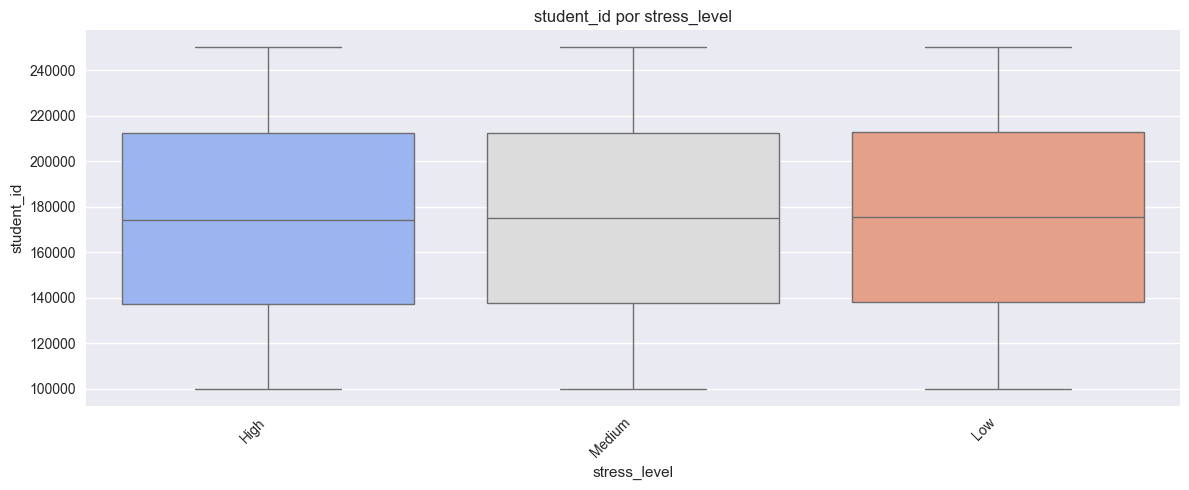

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


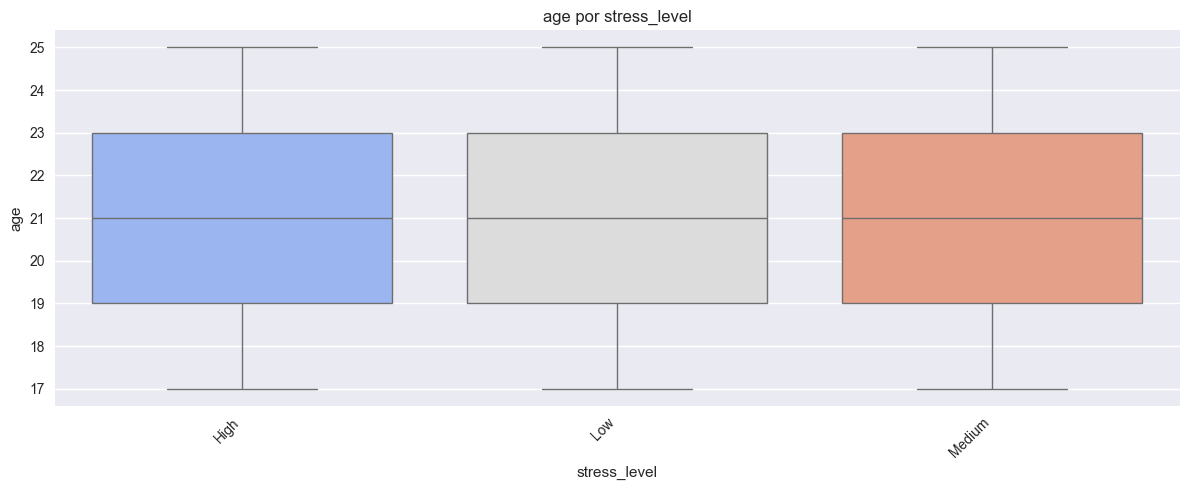

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


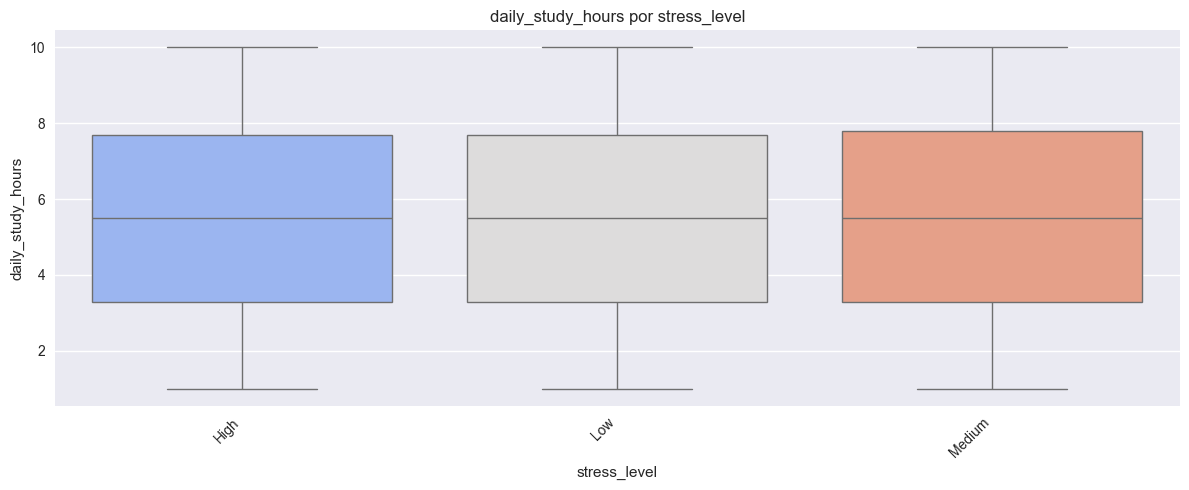

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


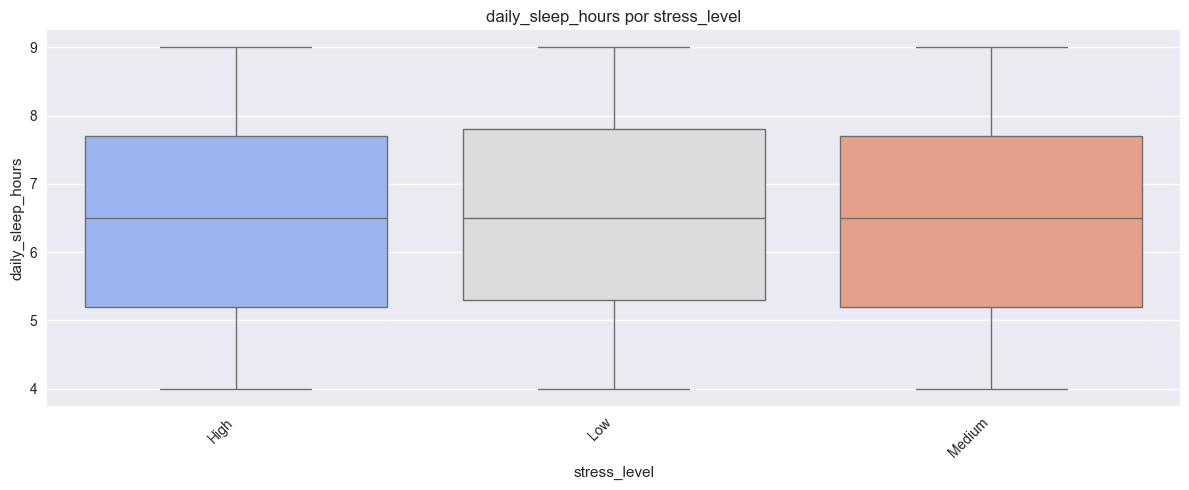

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


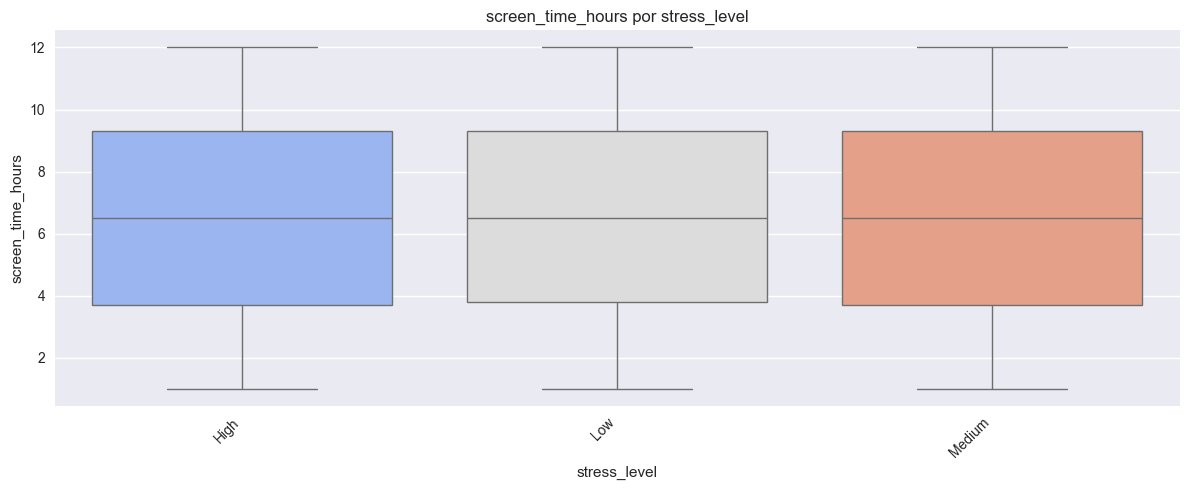

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


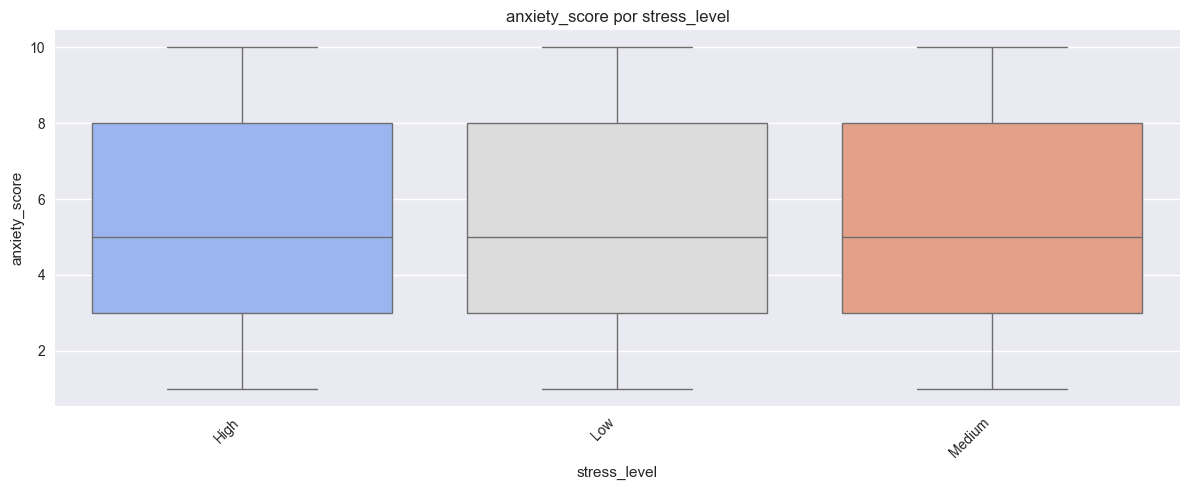

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


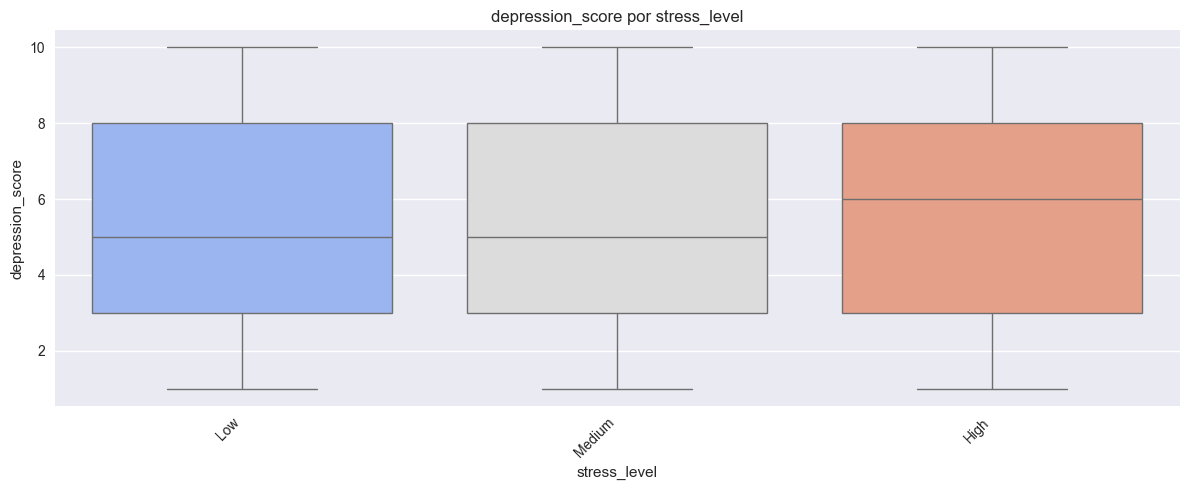

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


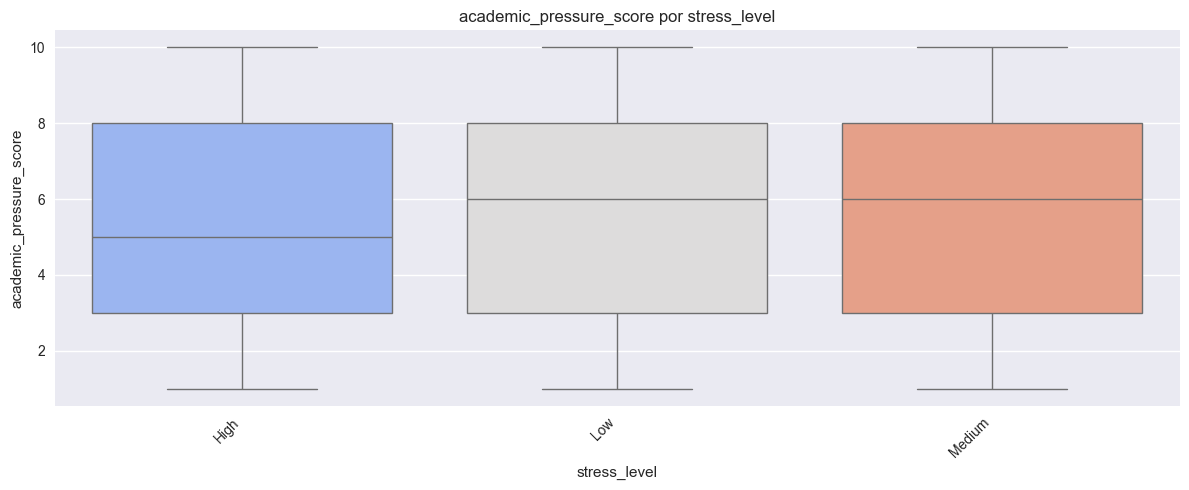

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


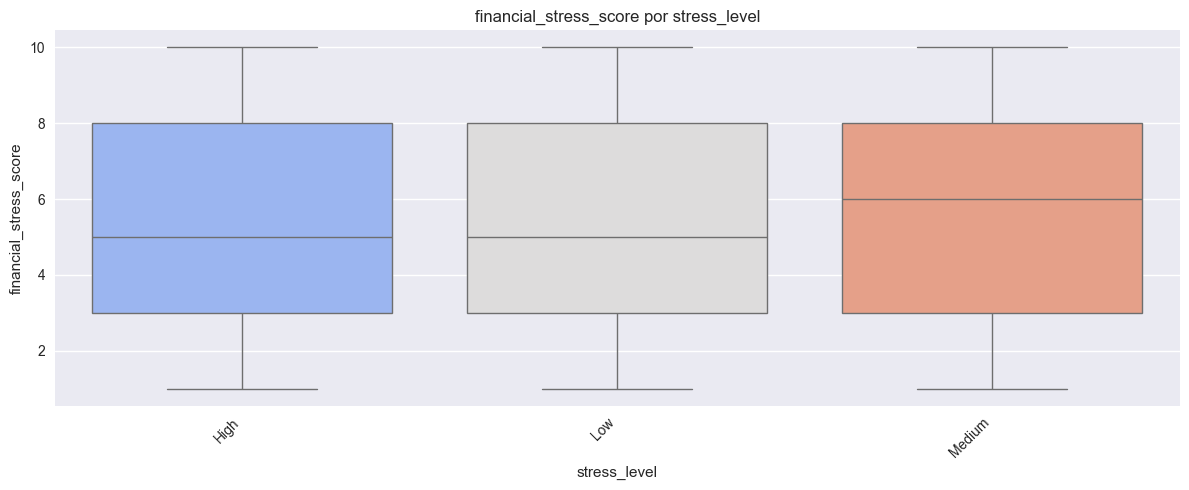

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


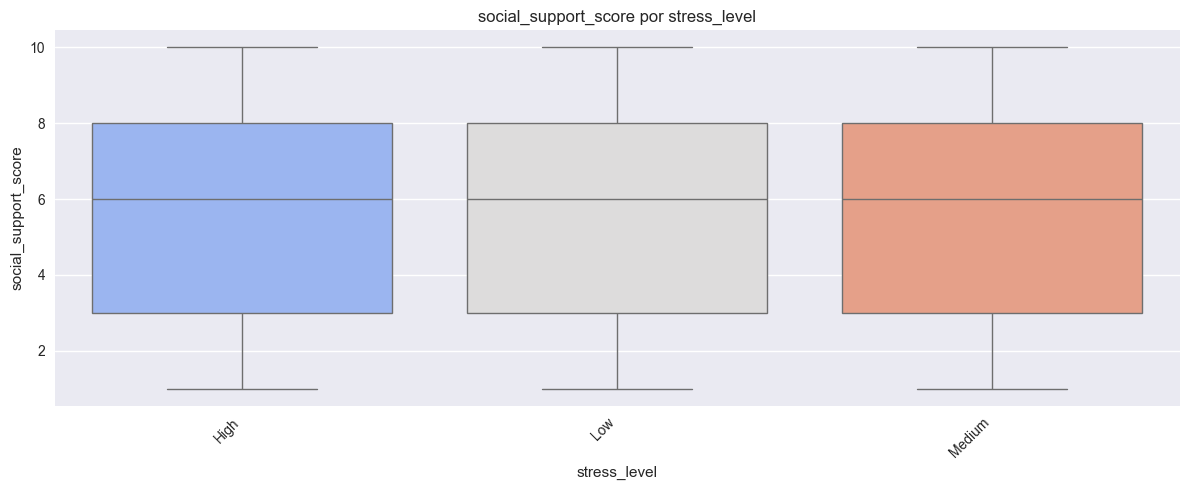

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


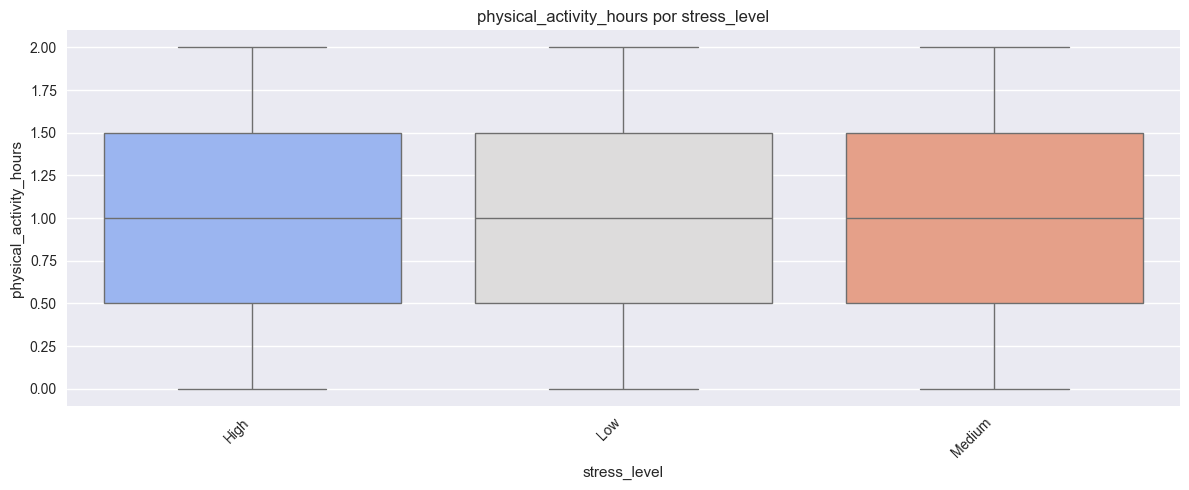

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


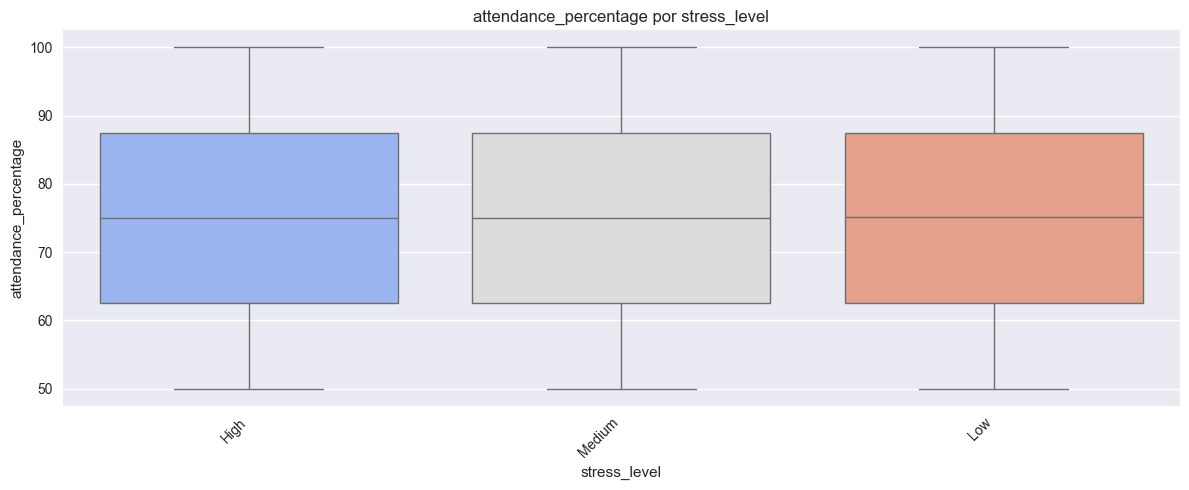

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


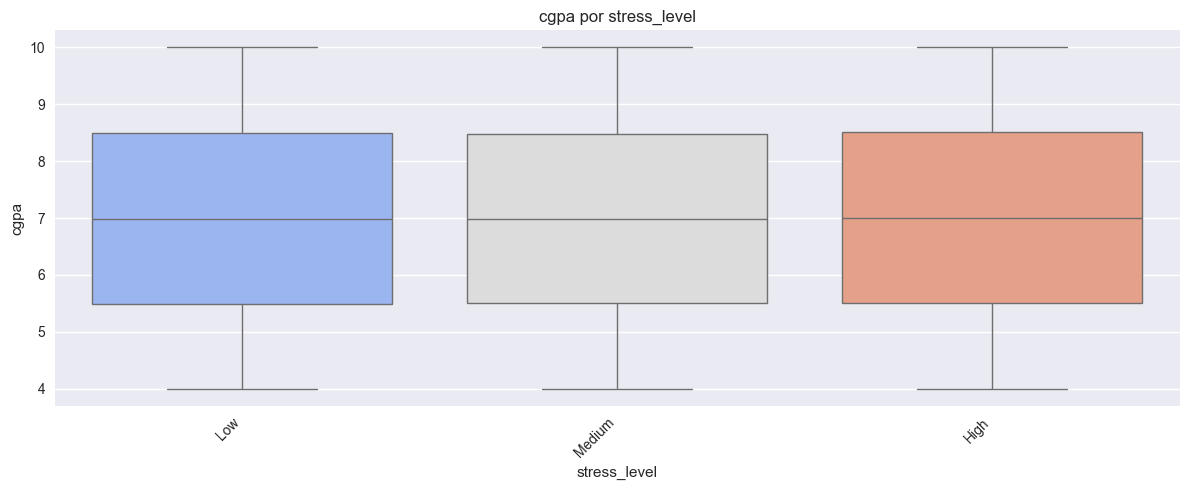

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


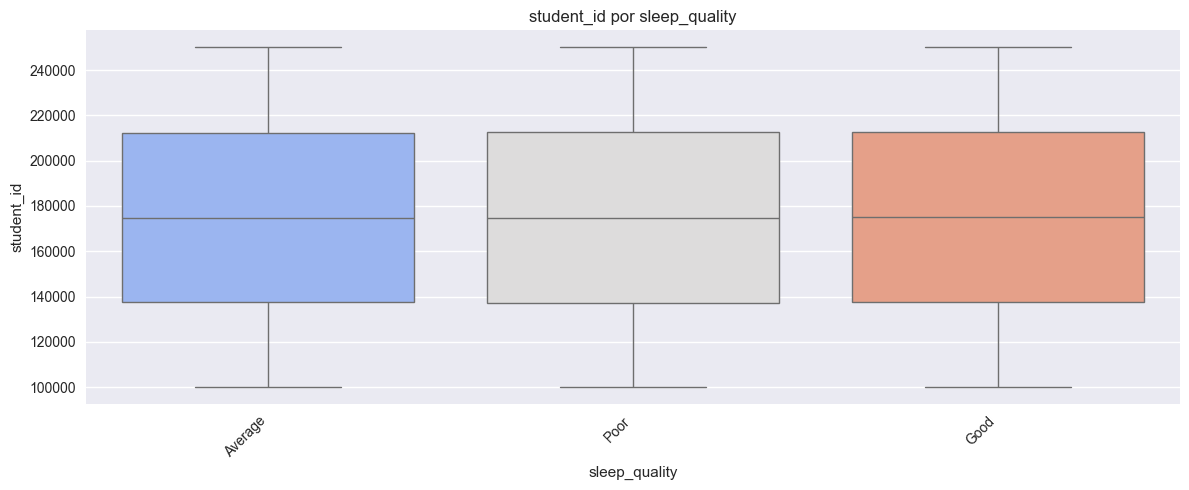

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


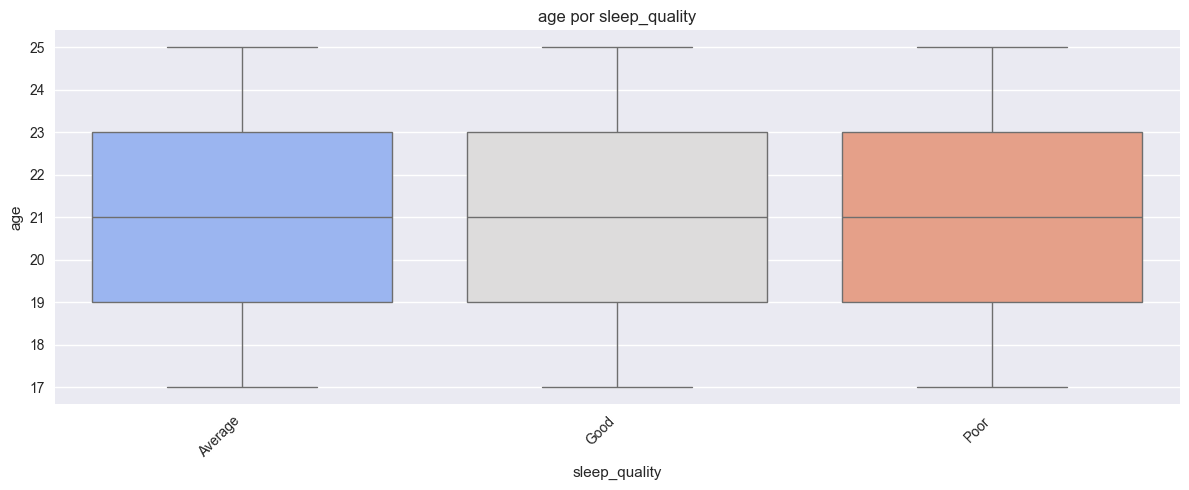

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


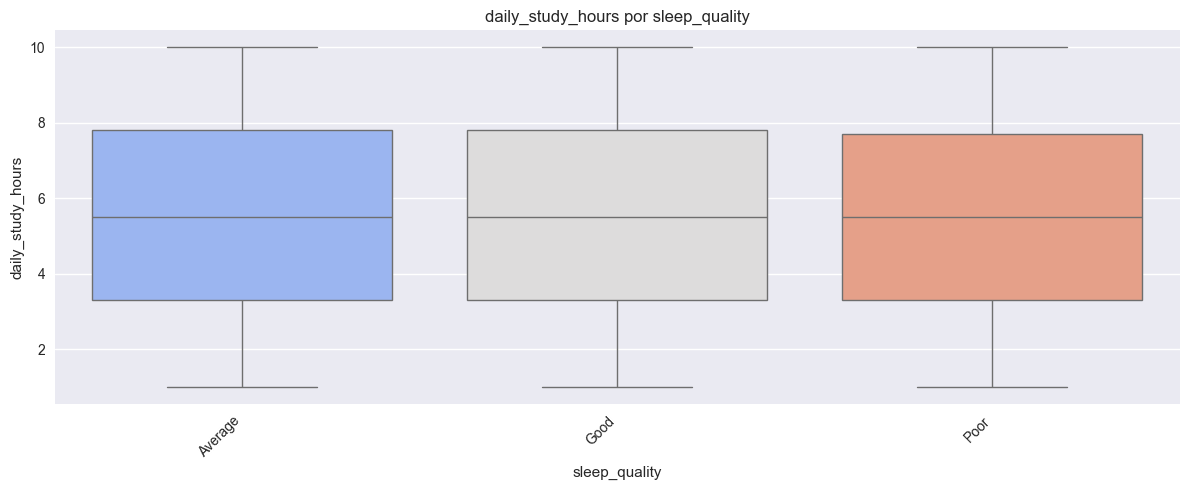

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


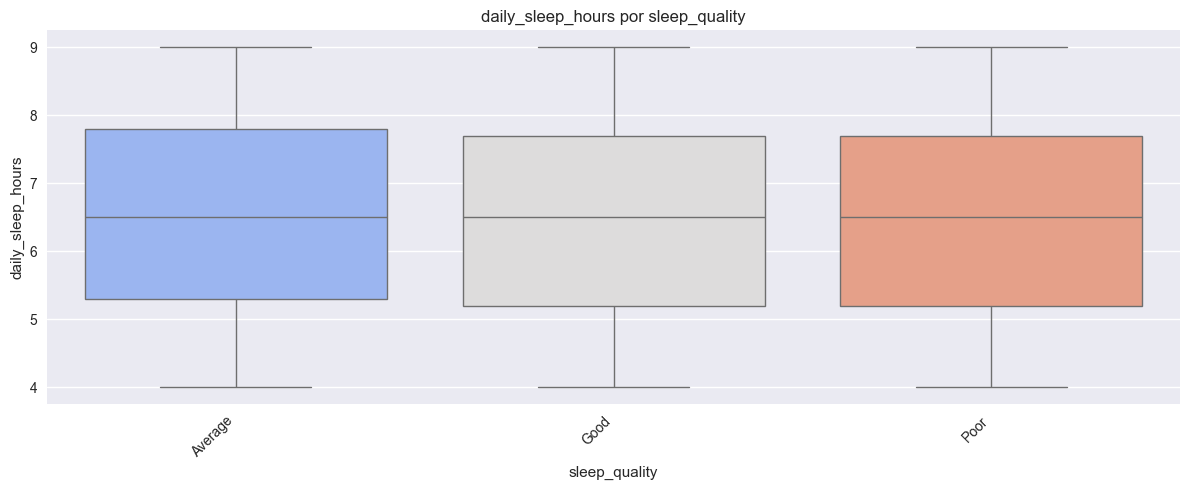

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


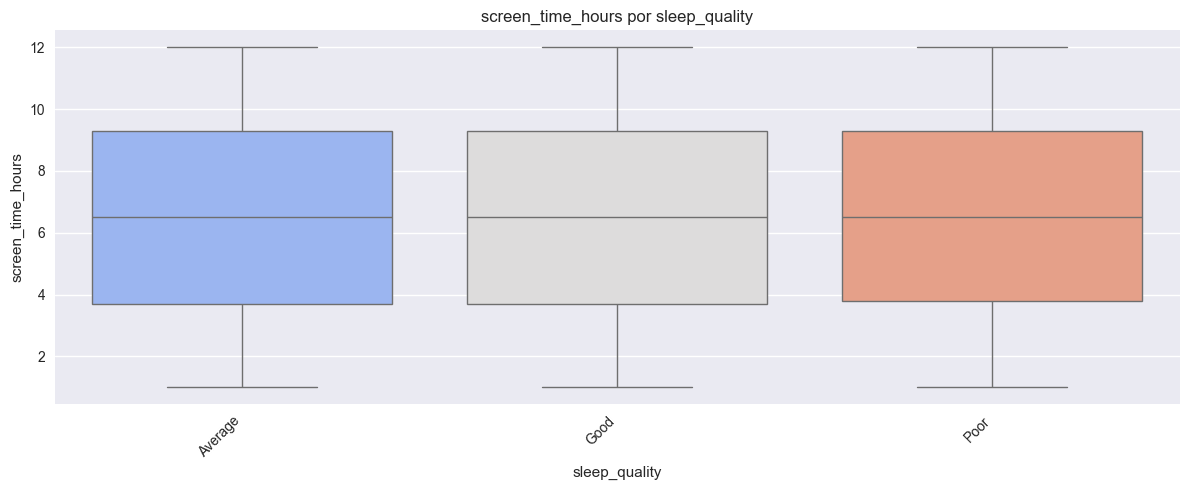

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


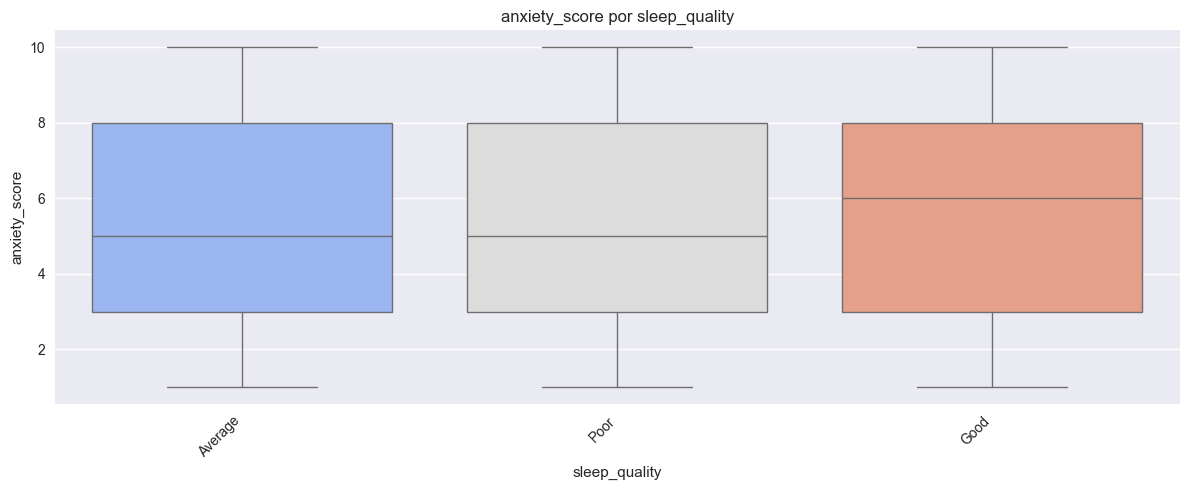

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


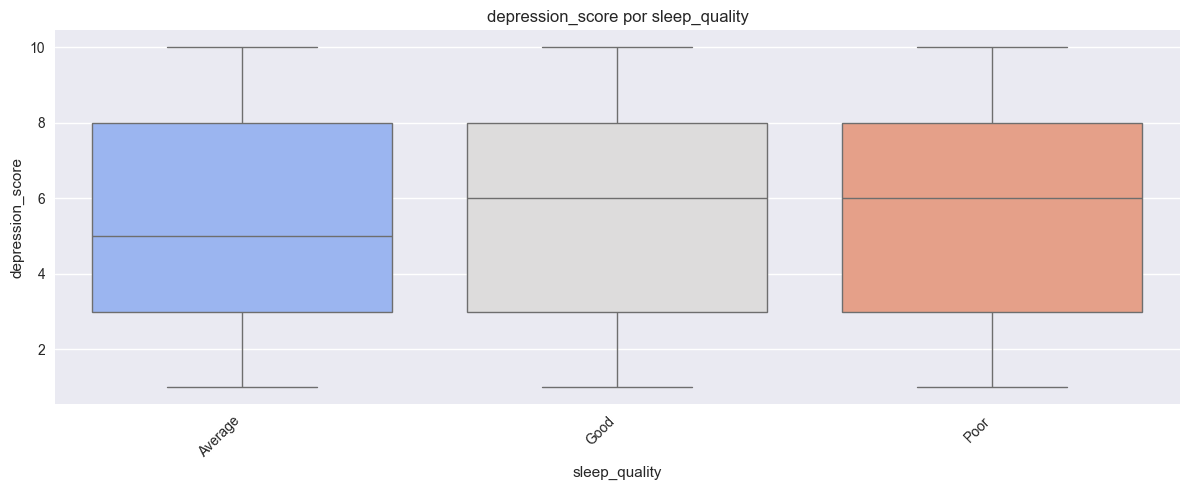

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


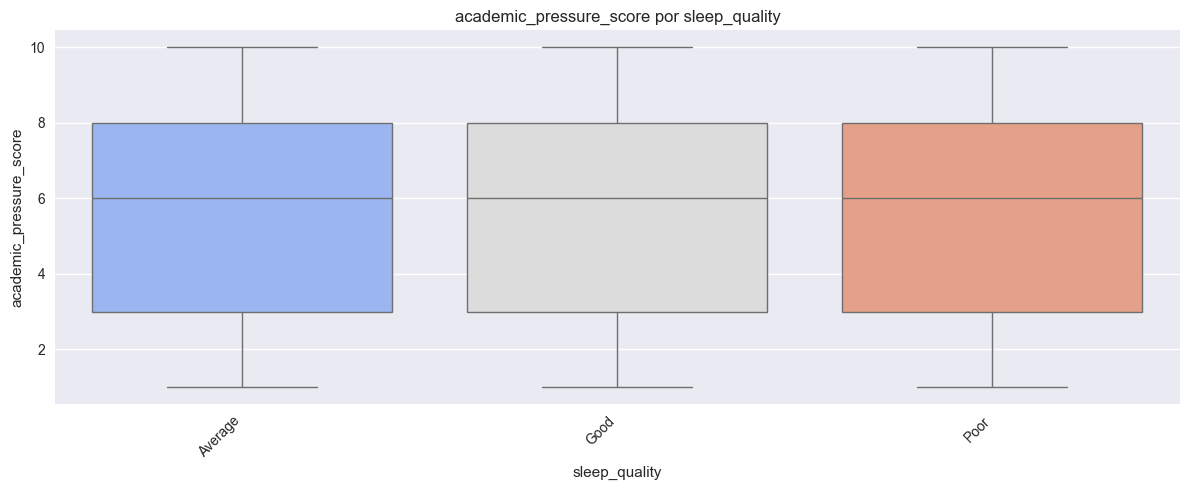

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


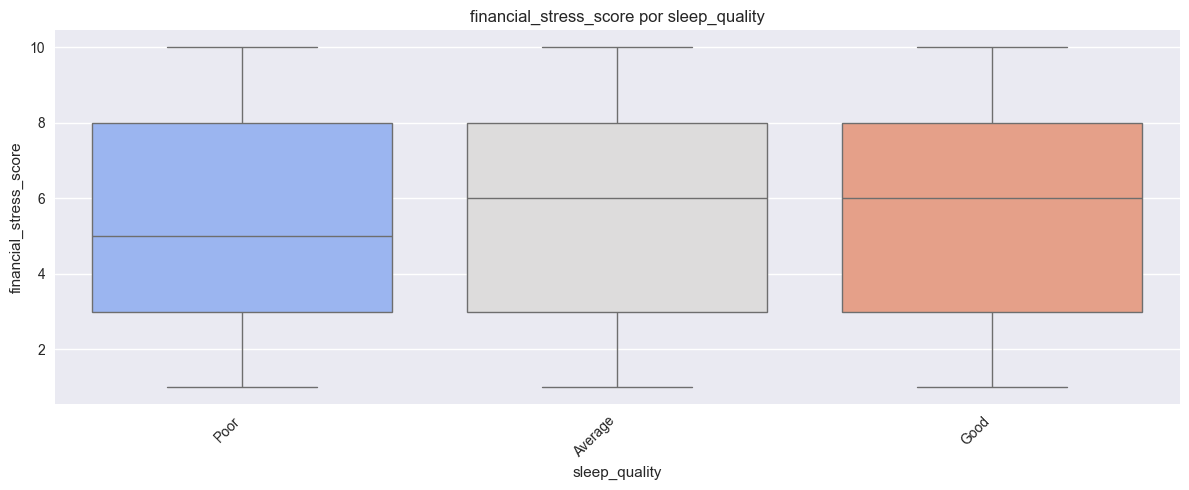

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


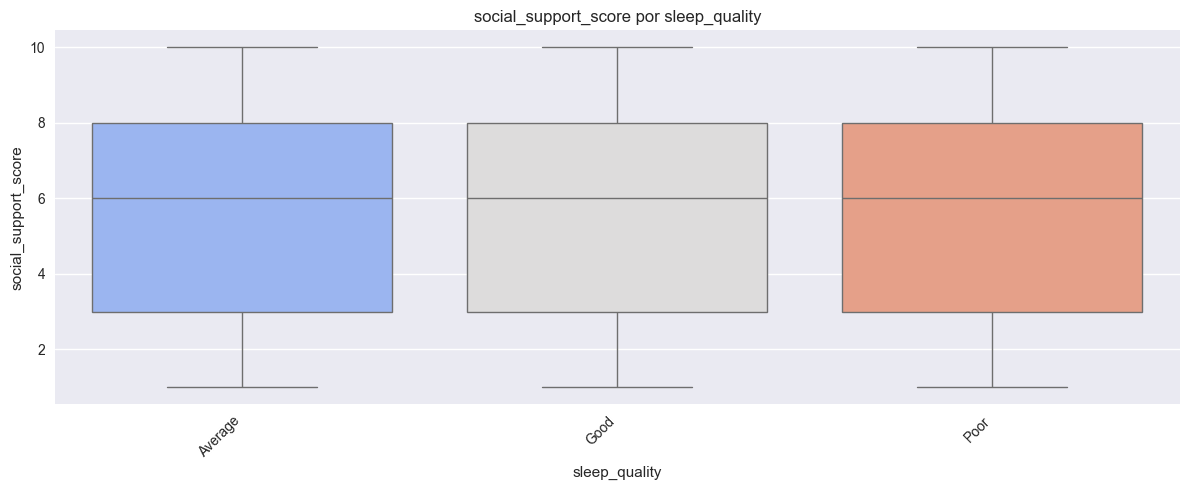

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


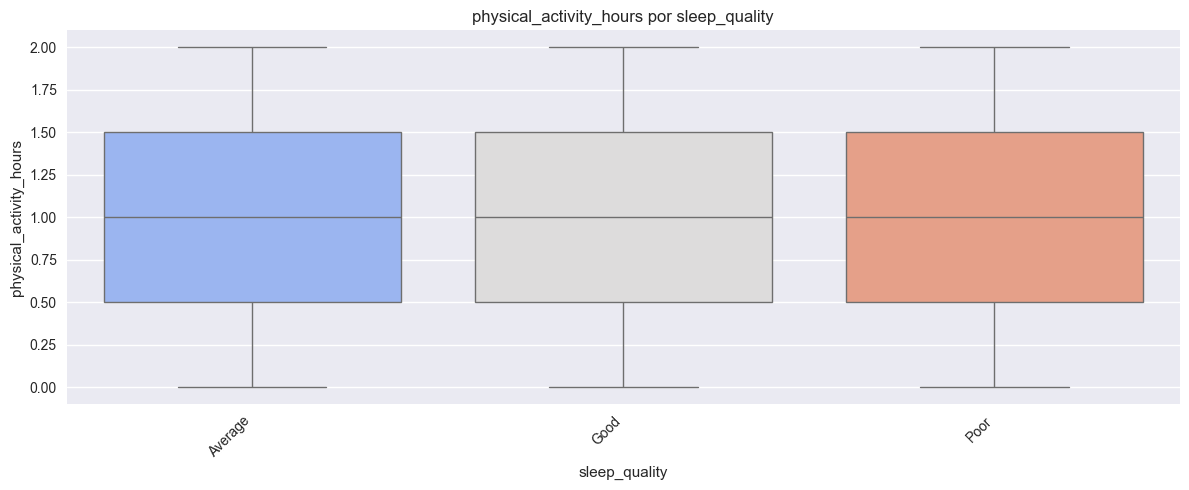

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


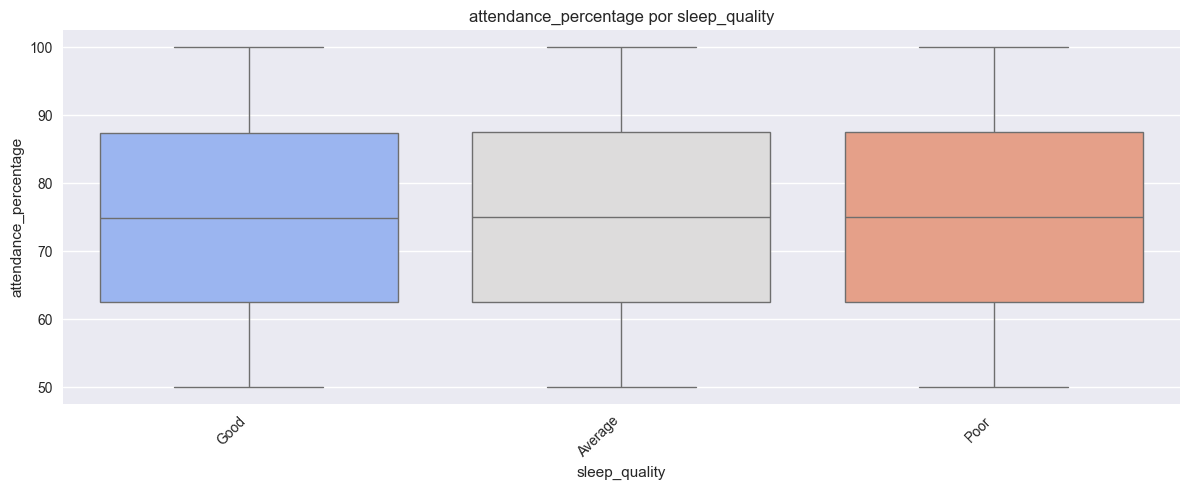

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


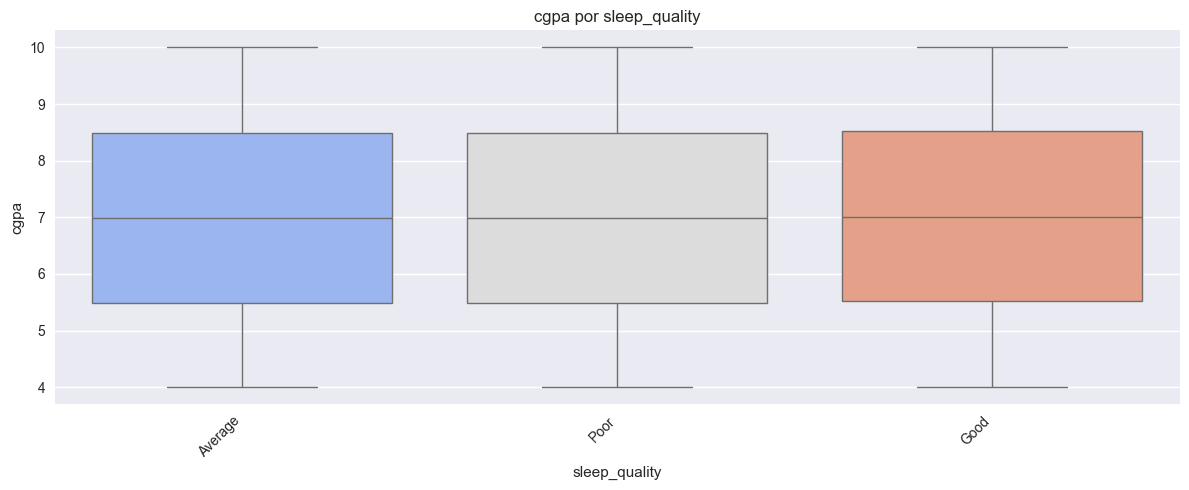

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


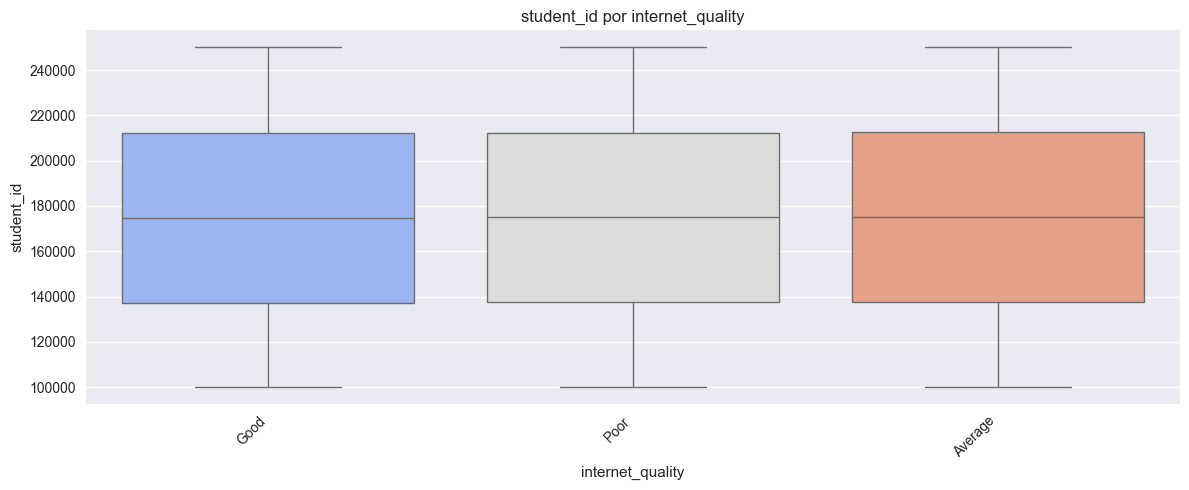

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


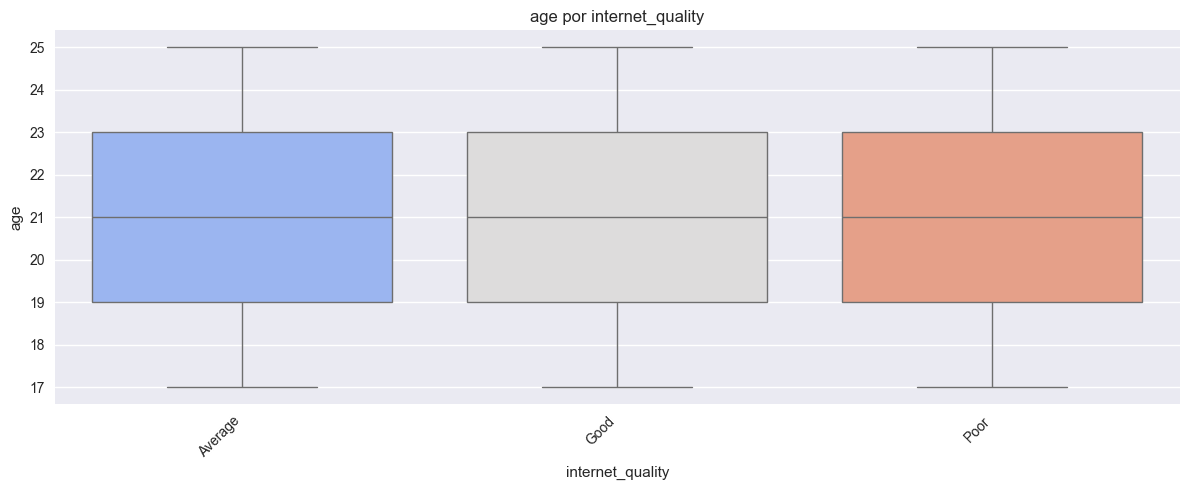

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


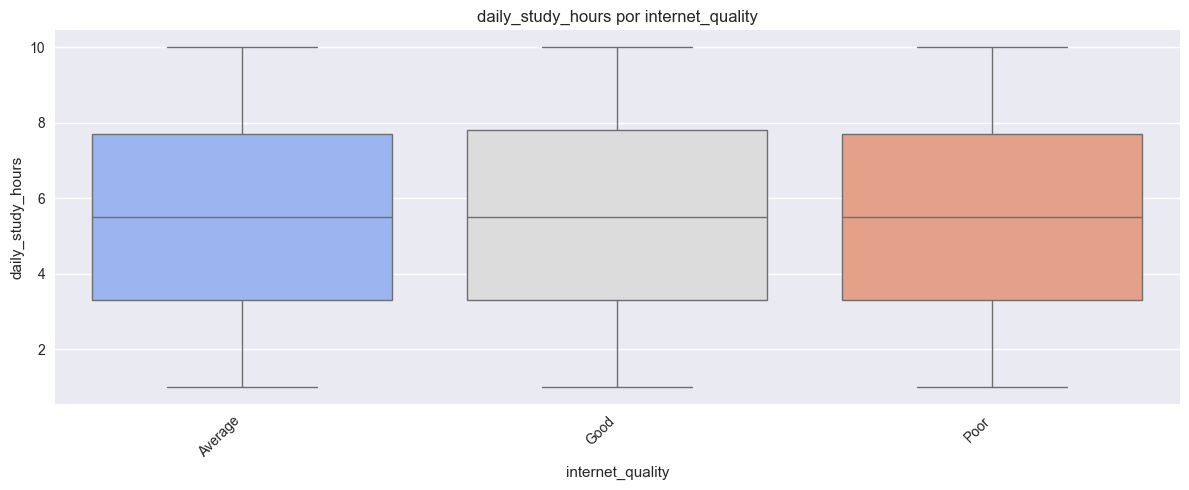

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


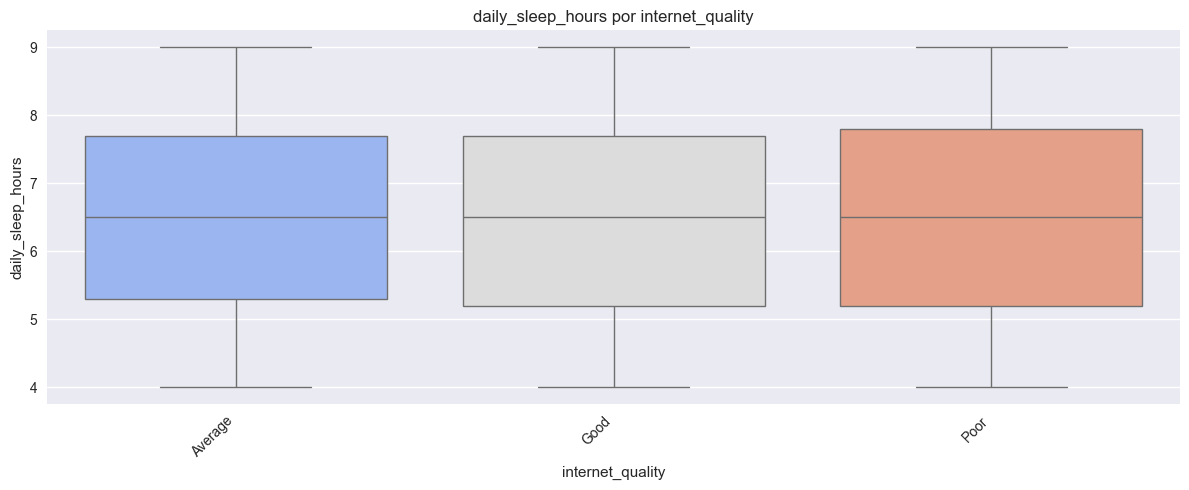

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


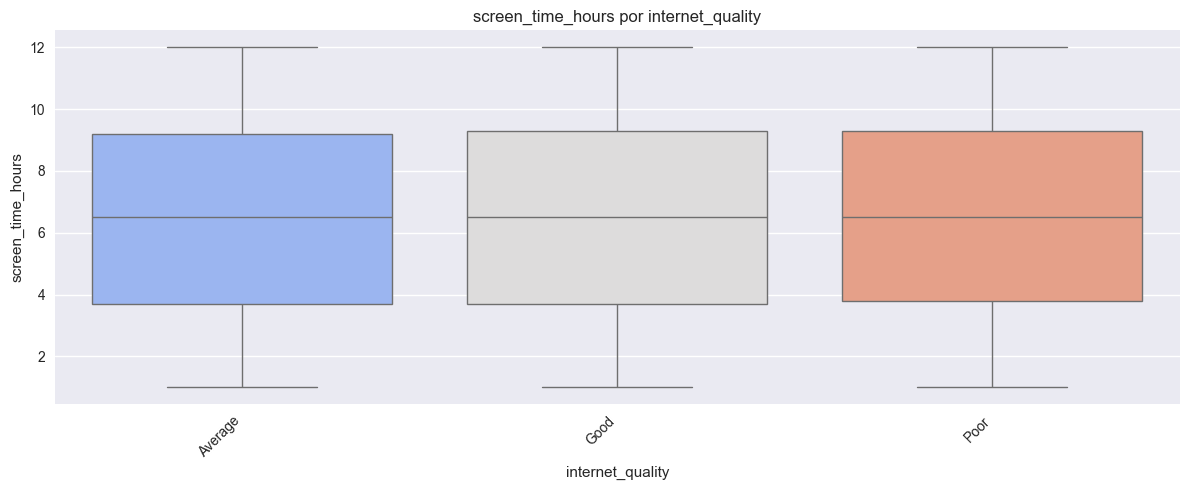

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


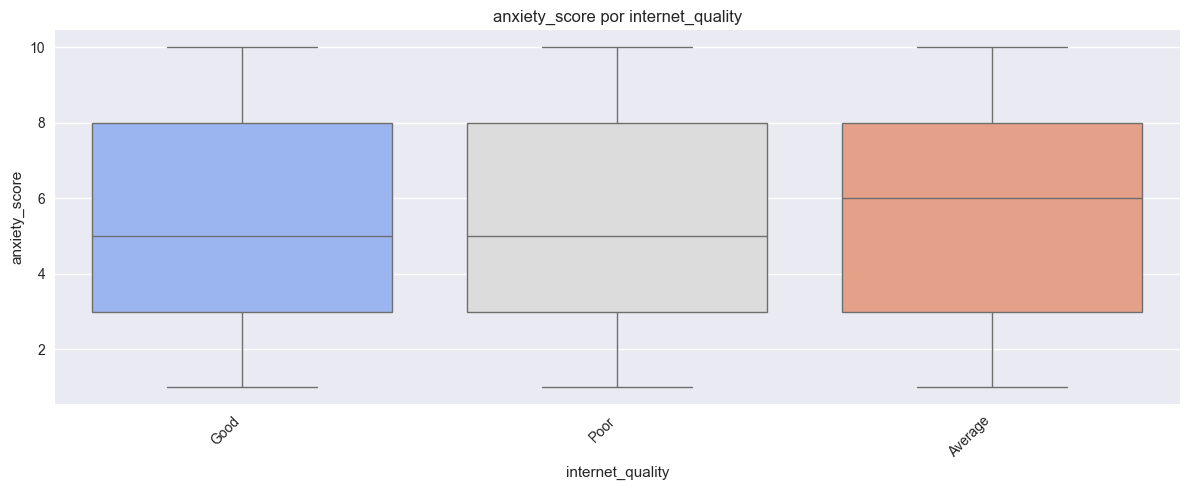

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


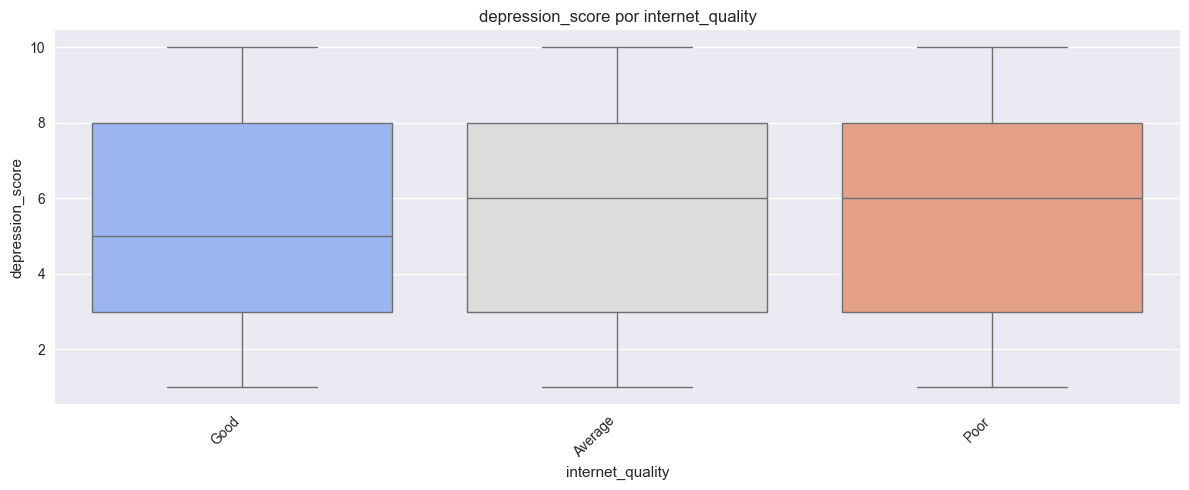

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


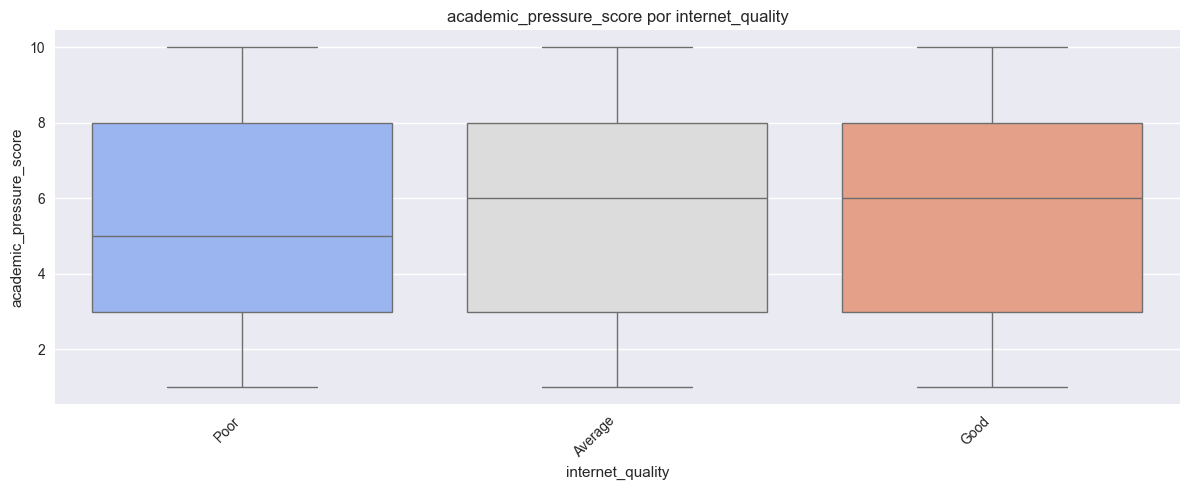

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


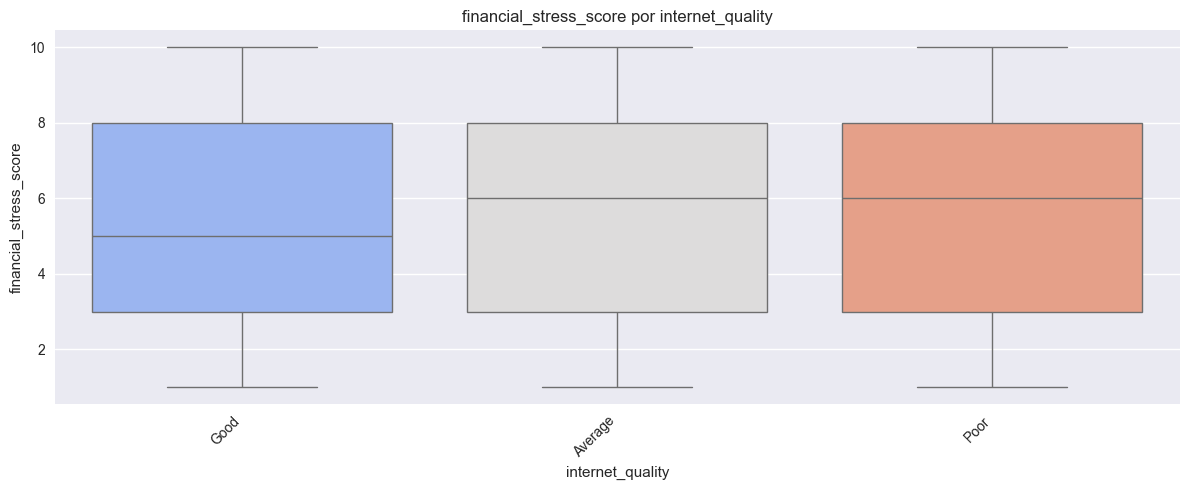

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


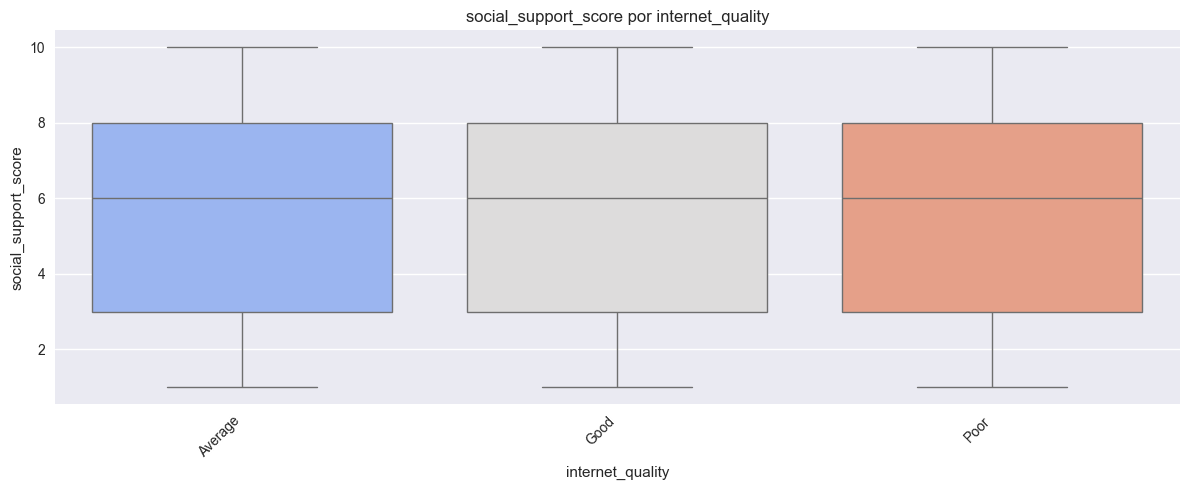

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


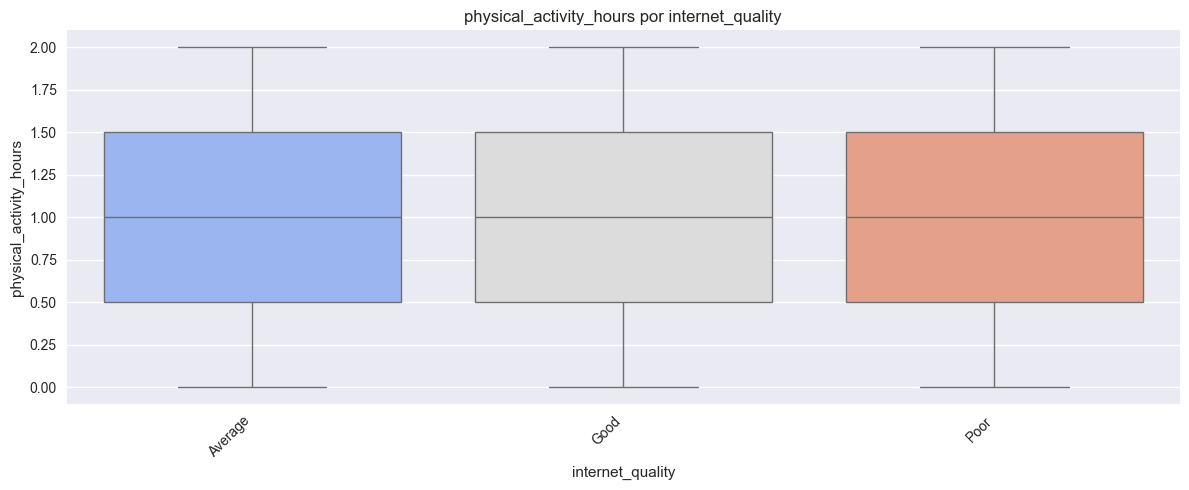

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


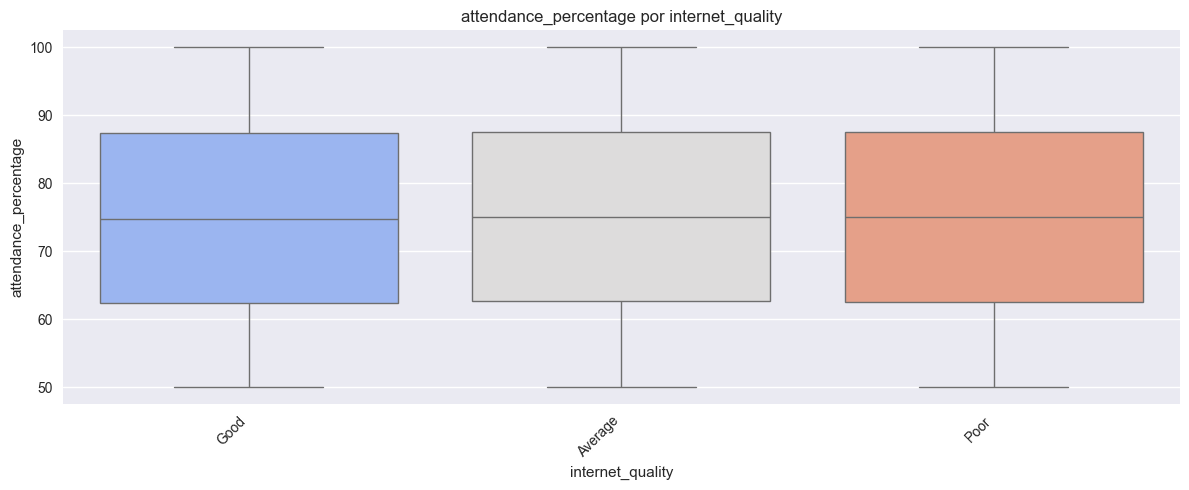

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


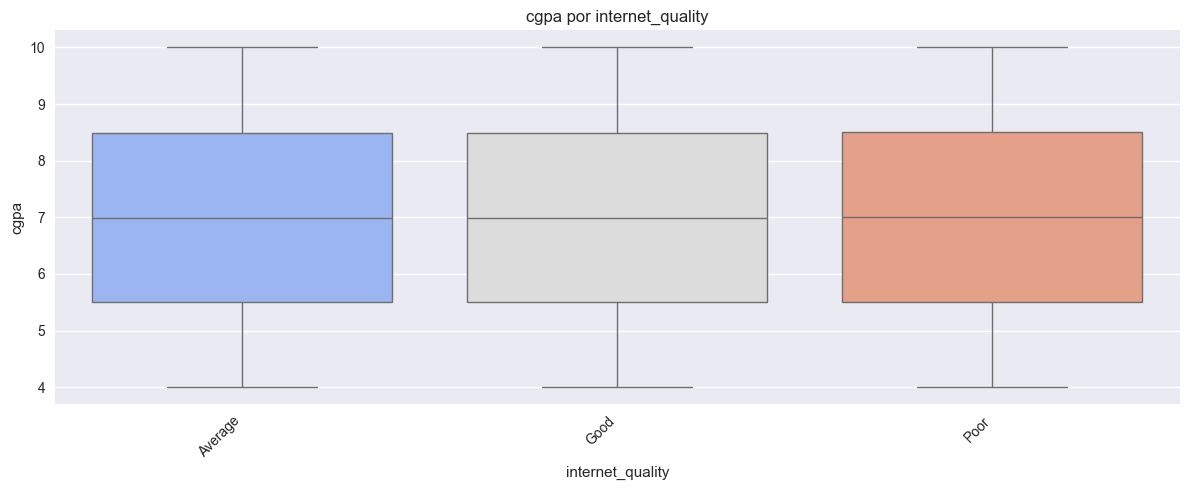

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


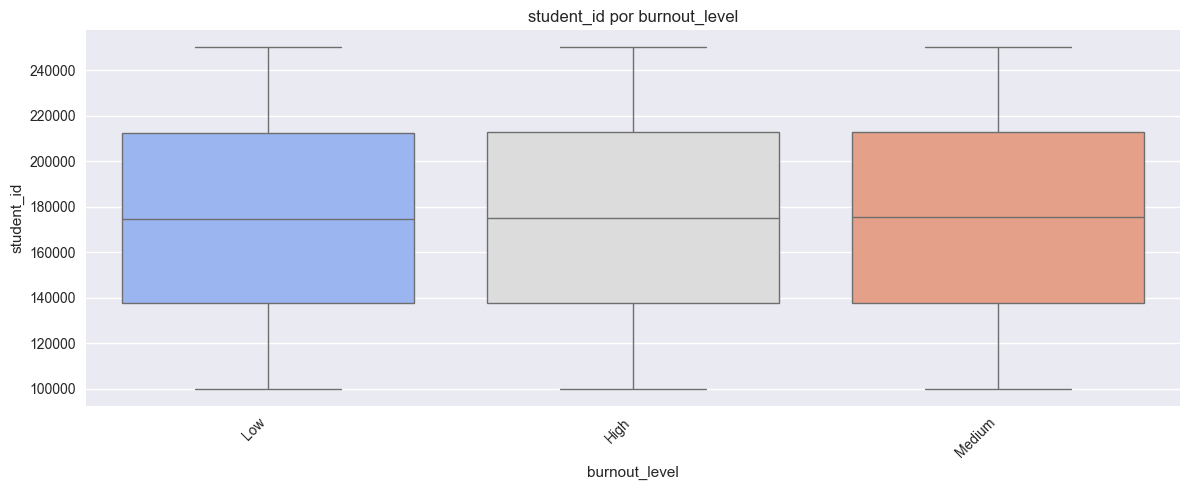

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


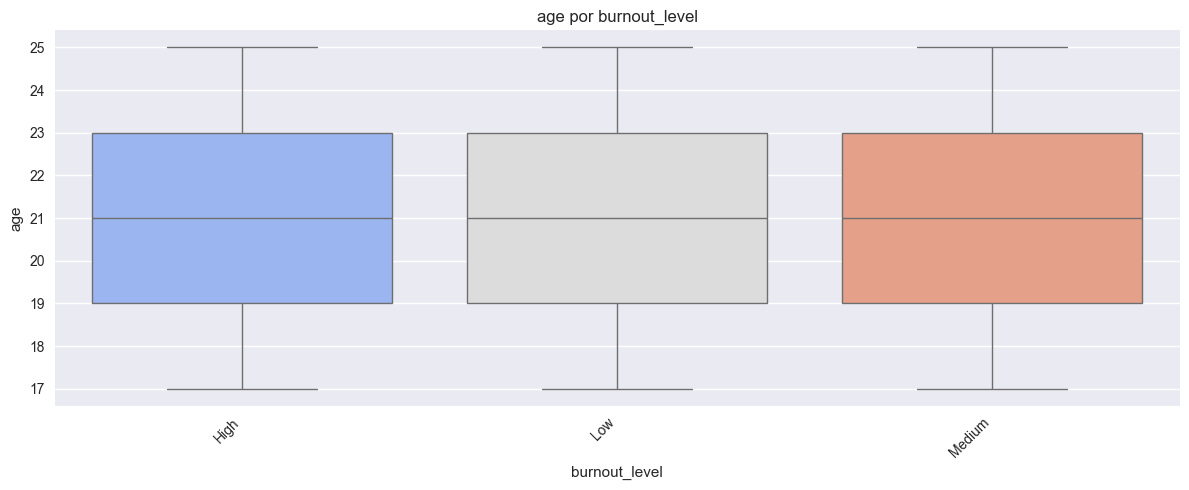

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


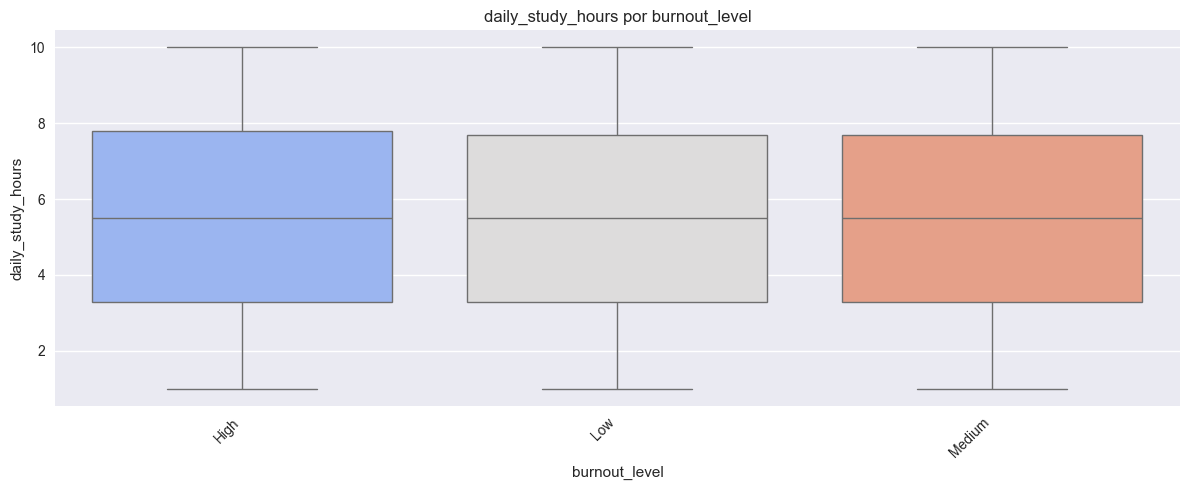

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


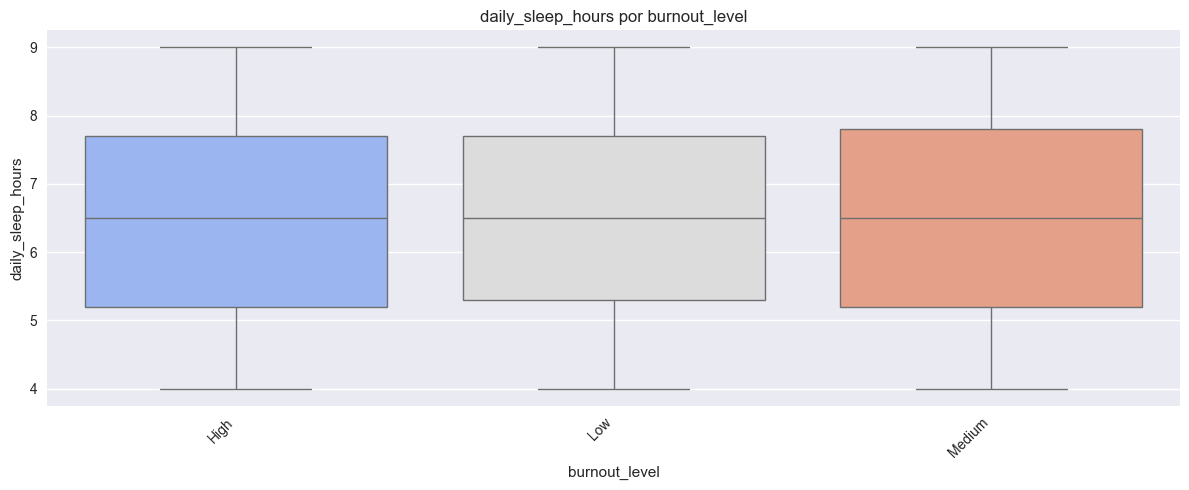

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


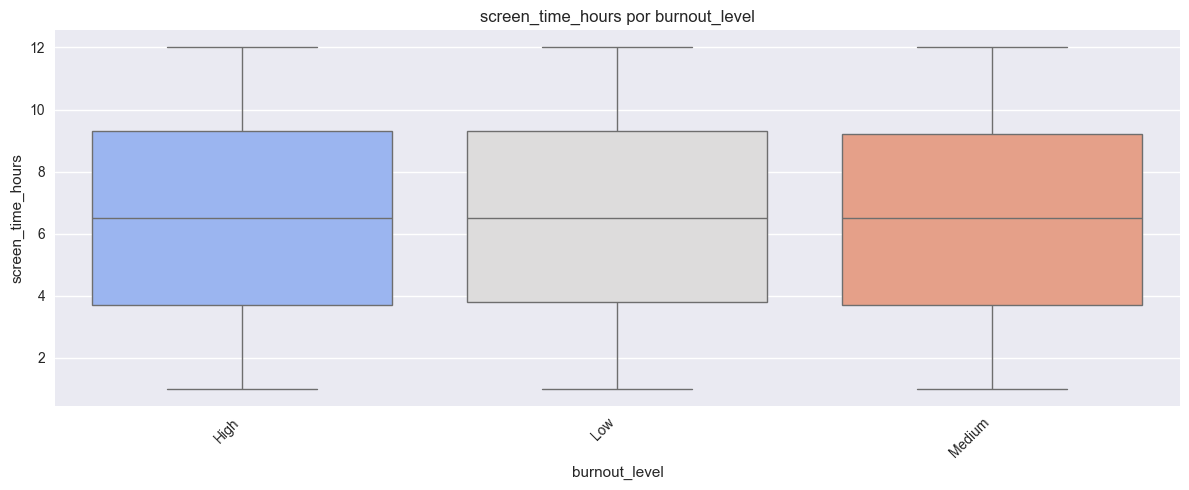

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


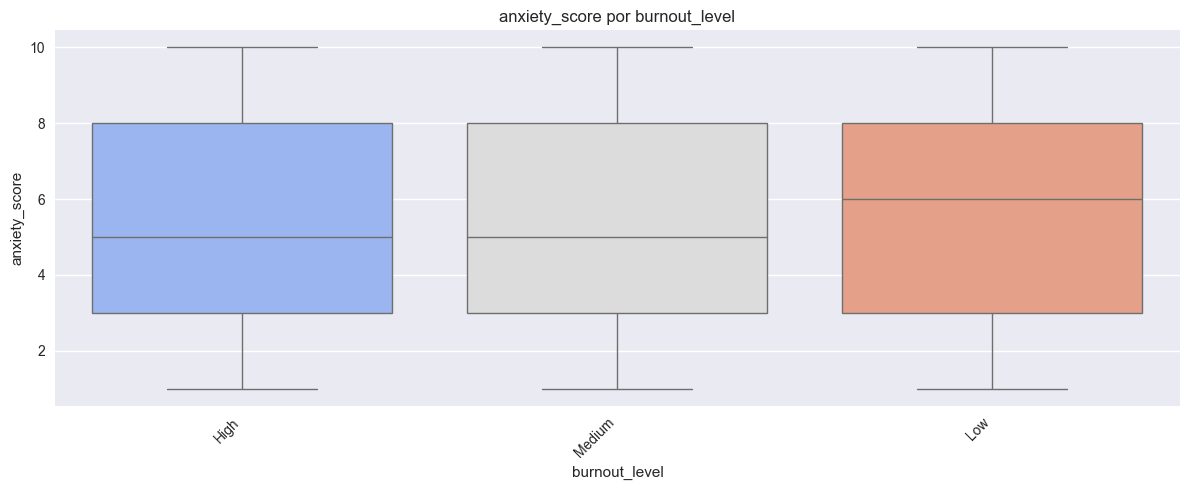

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


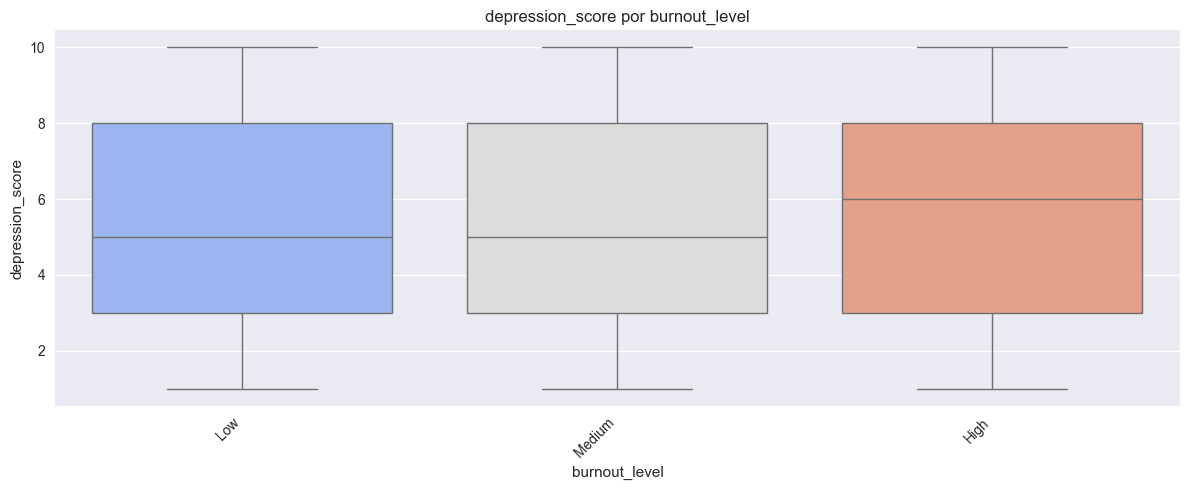

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


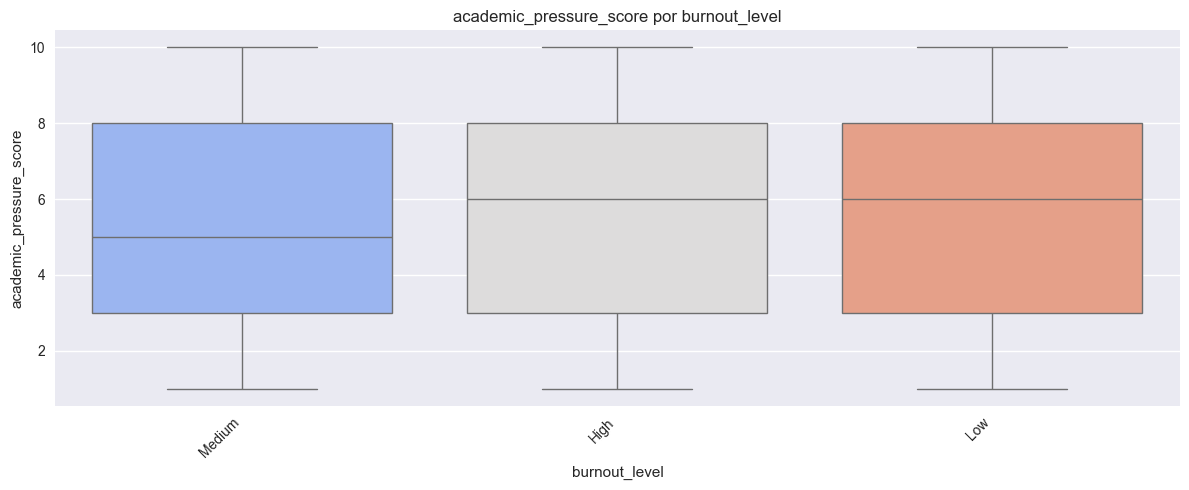

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


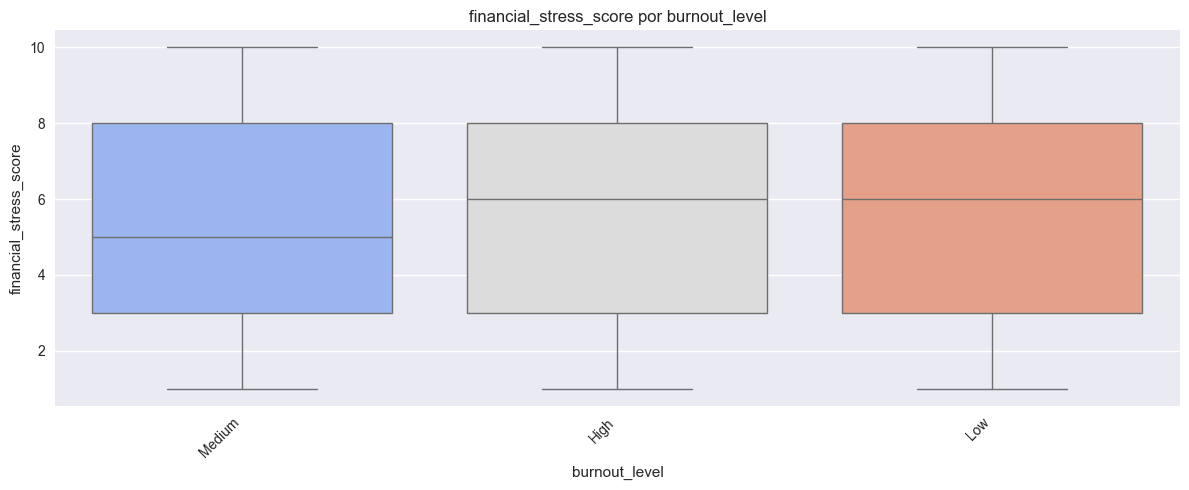

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


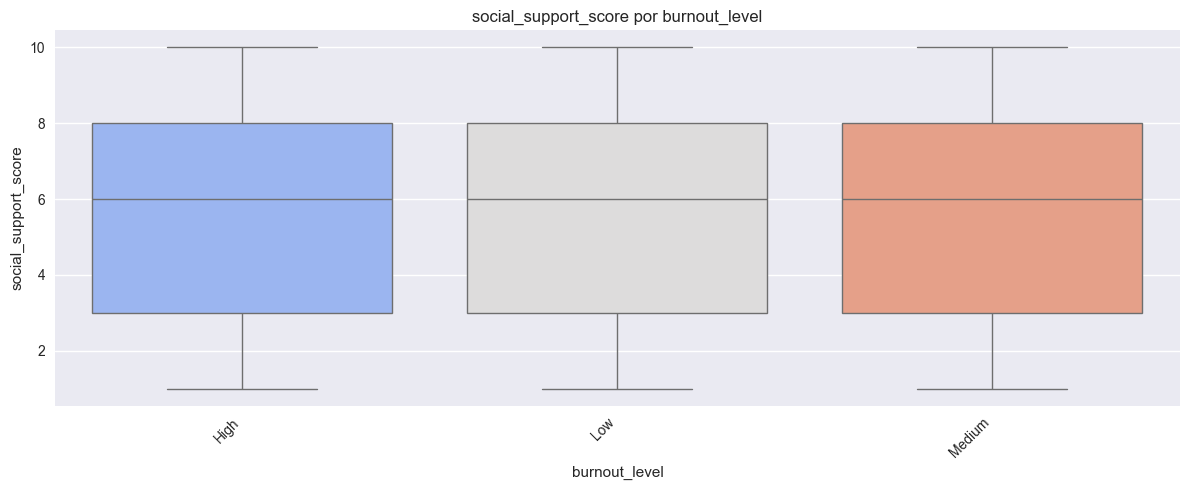

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


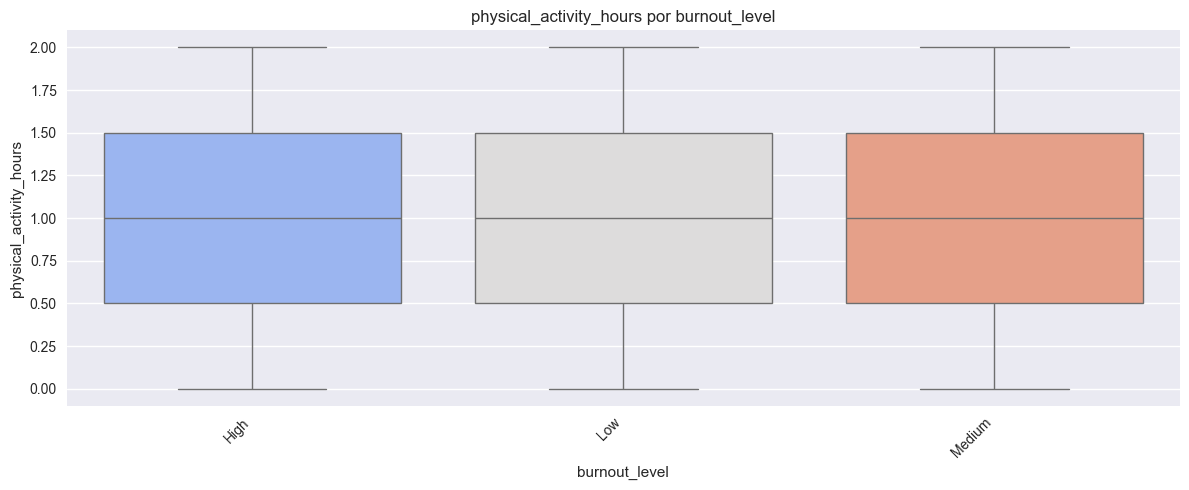

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


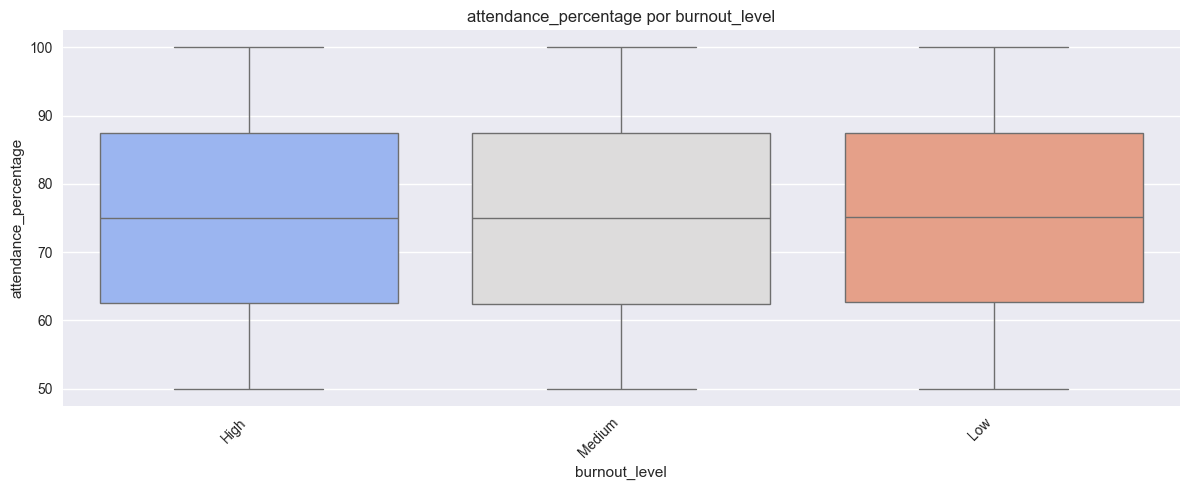

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')


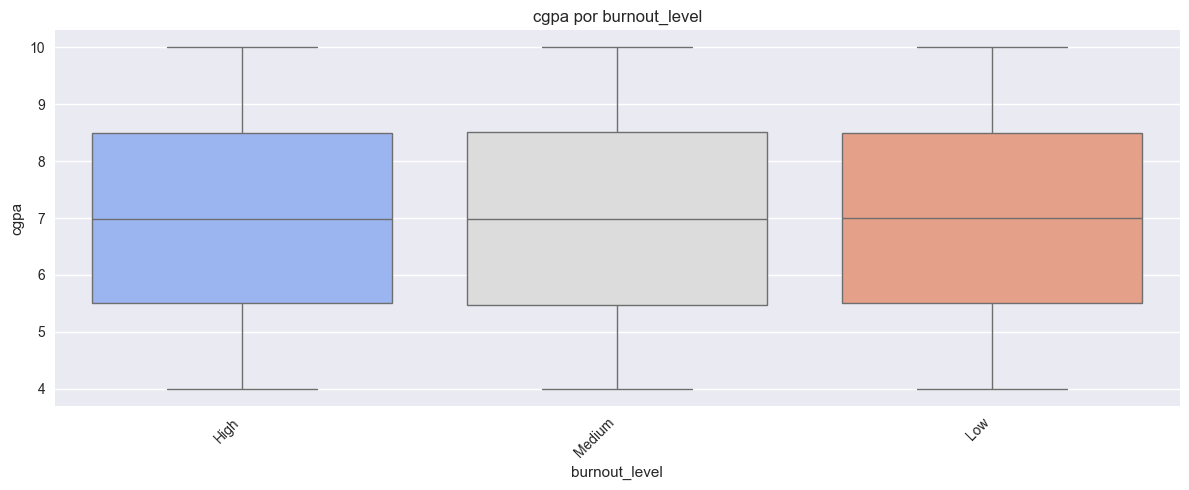

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9900\4158089693.py:177: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Estudiantes\Videos\MD\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


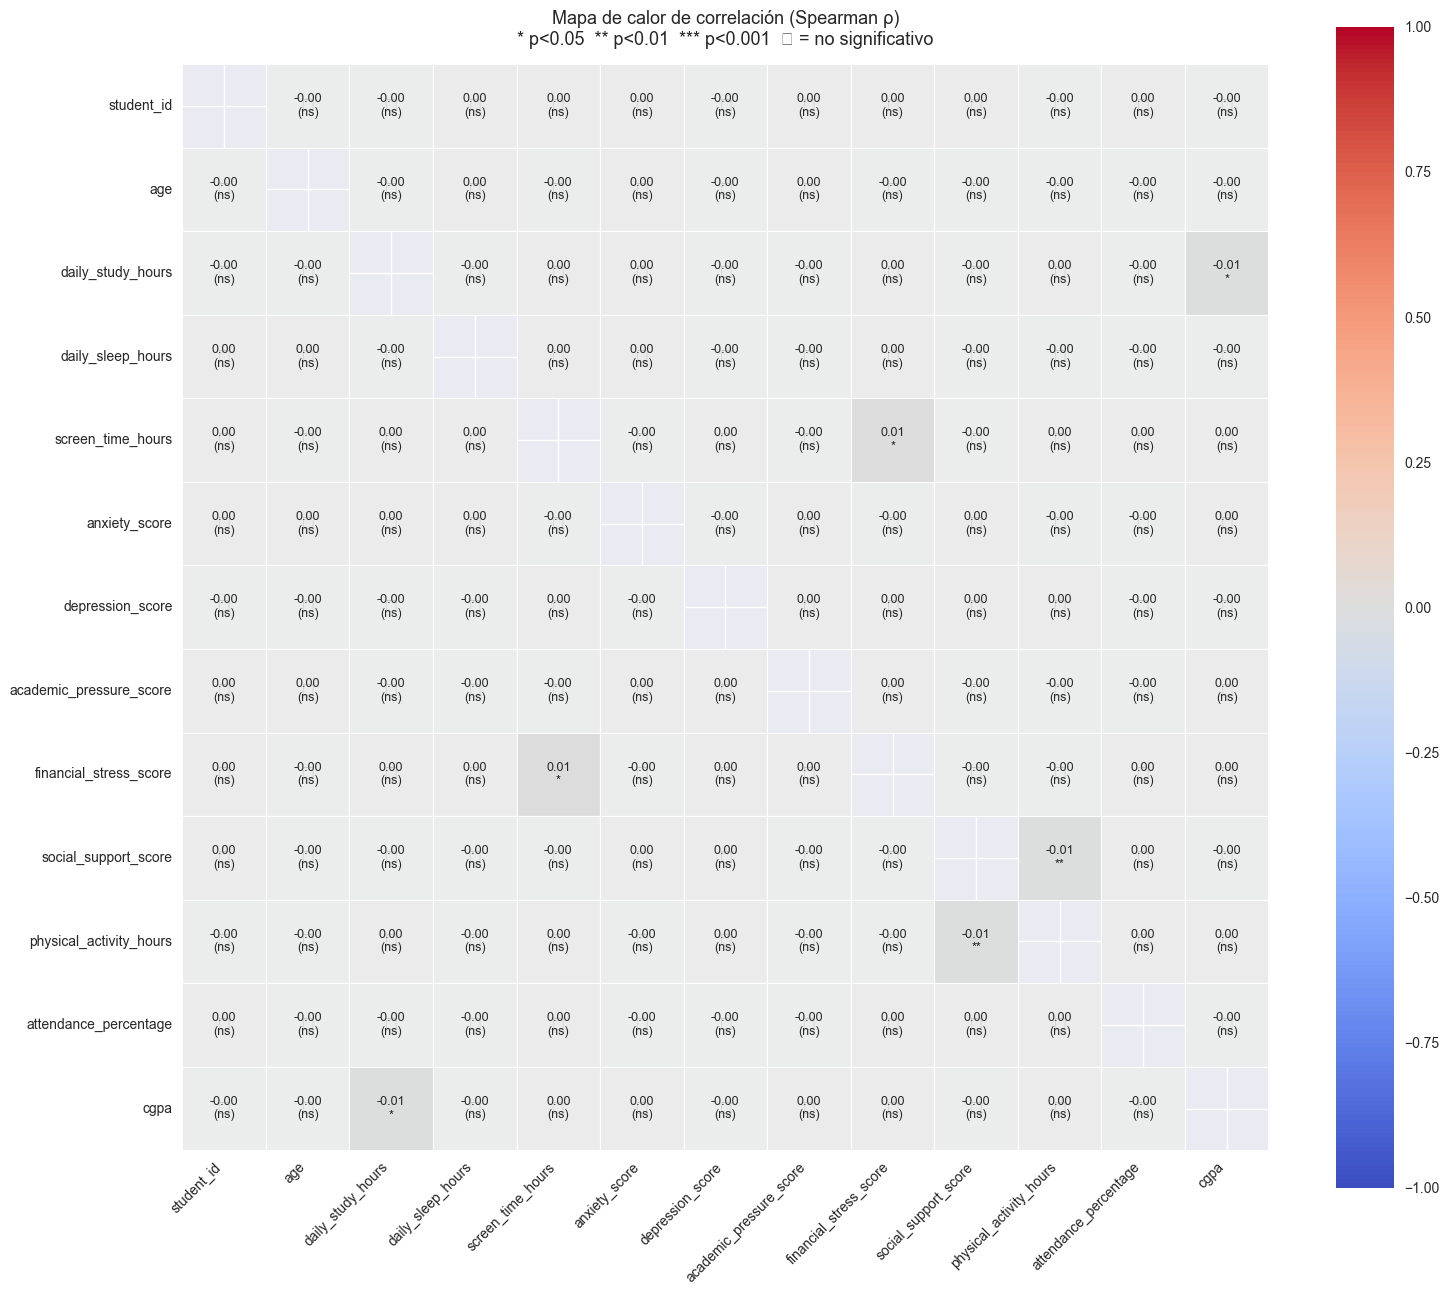


Top correlaciones significativas (spearman):
──────────────────────────────────────────────────
  social_support_score           ↔ physical_activity_hours         ρ=-0.007  p=0.0051 **
  screen_time_hours              ↔ financial_stress_score          ρ=+0.006  p=0.0132 *
  daily_study_hours              ↔ cgpa                            ρ=-0.005  p=0.0347 *


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, kendalltau


# ─────────────────────────────────────────────
# 1. DISTRIBUTIONS
# ─────────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram + KDE
    sns.histplot(df[col].dropna(), kde=True, bins=30, color='skyblue', ax=axes[0])
    axes[0].set_title(f'Distribución de {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frecuencia')

    # Q-Q plot to check normality visually
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot: {col}')

    plt.tight_layout()
    plt.show()

    # Shapiro-Wilk normality test (for n < 5000)
    sample = df[col].dropna()
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    stat, p = stats.shapiro(sample)
    normal = "✓ Normal" if p > 0.05 else "✗ Not normal"
    print(f"  {col}: Shapiro-Wilk p={p:.4f} → {normal}")


# ─────────────────────────────────────────────
# 2. BOXPLOTS BY CATEGORY
# ─────────────────────────────────────────────
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for cat in cat_cols:
    if df[cat].nunique() >= 20:
        continue
    for num in num_cols:
        plt.figure(figsize=(12, 5))
        order = df.groupby(cat)[num].median().sort_values().index
        sns.boxplot(x=df[cat], y=df[num], order=order, palette='coolwarm')
        plt.title(f'{num} por {cat}')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


# ─────────────────────────────────────────────
# 3. IMPROVED CORRELATION HEATMAP
# ─────────────────────────────────────────────
def compute_correlation_with_pvalues(df_numeric, method='spearman'):
    """
    Compute pairwise correlation + p-values.
    Returns: corr_matrix, pval_matrix
    """
    cols = df_numeric.columns
    n = len(cols)
    corr_mat = pd.DataFrame(np.ones((n, n)), columns=cols, index=cols)
    pval_mat = pd.DataFrame(np.zeros((n, n)), columns=cols, index=cols)

    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if i == j:
                corr_mat.loc[c1, c2] = 1.0
                pval_mat.loc[c1, c2] = 0.0
                continue
            x = df_numeric[c1].dropna()
            y = df_numeric[c2].dropna()
            # Align on common index
            valid = x.index.intersection(y.index)
            x, y = x.loc[valid], y.loc[valid]

            if len(x) < 3:
                corr_mat.loc[c1, c2] = np.nan
                pval_mat.loc[c1, c2] = np.nan
                continue

            if method == 'spearman':
                r, p = spearmanr(x, y)
            elif method == 'kendall':
                r, p = kendalltau(x, y)
            else:  # pearson
                r, p = stats.pearsonr(x, y)

            corr_mat.loc[c1, c2] = r
            pval_mat.loc[c1, c2] = p

    return corr_mat, pval_mat


if len(num_cols) > 1:
    df_num = df[num_cols].copy()

    # ── Choose method based on your data ──────────────────────────────────
    # 'pearson'  → normally distributed, linear relationships
    # 'spearman' → skewed, outliers, ordinal, or non-linear monotonic (recommended default)
    # 'kendall'  → small samples, many ties
    METHOD = 'spearman'  # ← change this to suit your data

    corr, pvals = compute_correlation_with_pvalues(df_num, method=METHOD)

    # ── Significance mask: blank out pairs where p > 0.05 ─────────────────
    sig_mask = pvals > 0.05          # True = NOT significant → will be masked
    diag_mask = np.eye(len(corr), dtype=bool)

    # ── Annotation: show value + star if significant ───────────────────────
    annot = corr.copy().astype(object)
    for i in corr.index:
        for j in corr.columns:
            val = corr.loc[i, j]
            p   = pvals.loc[i, j]
            if i == j:
                annot.loc[i, j] = ''
            elif pd.isna(val):
                annot.loc[i, j] = 'n/a'
            elif p <= 0.001:
                annot.loc[i, j] = f'{val:.2f}\n***'
            elif p <= 0.01:
                annot.loc[i, j] = f'{val:.2f}\n**'
            elif p <= 0.05:
                annot.loc[i, j] = f'{val:.2f}\n*'
            else:
                annot.loc[i, j] = f'{val:.2f}\n(ns)'  # not significant

    # ── Plot ───────────────────────────────────────────────────────────────
    n_vars = len(num_cols)
    fig_size = max(10, n_vars * 1.2)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.85))

    sns.heatmap(
        corr,
        annot=annot,
        fmt='',                      # we handle formatting ourselves
        cmap='coolwarm',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        linecolor='white',
        square=True,
        mask=diag_mask,              # hide the diagonal (always 1.0, adds noise)
        annot_kws={'size': 9, 'va': 'center'},
        ax=ax
    )

    # Cross out non-significant cells with an X overlay
    for i, row in enumerate(corr.index):
        for j, col in enumerate(corr.columns):
            if sig_mask.loc[row, col] and row != col:
                ax.add_patch(plt.Rectangle(
                    (j, i), 1, 1,
                    fill=True, color='white', alpha=0.45, zorder=2
                ))
                ax.text(
                    j + 0.5, i + 0.5, '✕',
                    ha='center', va='center',
                    fontsize=14, color='gray', alpha=0.6, zorder=3
                )

    method_label = {'spearman': "Spearman ρ", 'pearson': "Pearson r", 'kendall': "Kendall τ"}
    ax.set_title(
        f'Mapa de calor de correlación ({method_label[METHOD]})\n'
        f'* p<0.05  ** p<0.01  *** p<0.001  ✕ = no significativo',
        fontsize=13, pad=14
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

    plt.tight_layout()
    plt.show()

    # ── Summary: top significant correlations ─────────────────────────────
    print(f"\nTop correlaciones significativas ({METHOD}):")
    print("─" * 50)
    pairs = []
    seen = set()
    for i, r in enumerate(corr.index):
        for j, c in enumerate(corr.columns):
            if i >= j:
                continue
            p = pvals.loc[r, c]
            v = corr.loc[r, c]
            if p <= 0.05 and not pd.isna(v):
                pairs.append((abs(v), v, p, r, c))

    if pairs:
        pairs.sort(reverse=True)
        for _, v, p, r, c in pairs[:15]:
            stars = '***' if p <= 0.001 else ('**' if p <= 0.01 else '*')
            print(f"  {r:30s} ↔ {c:30s}  ρ={v:+.3f}  p={p:.4f} {stars}")
    else:
        print("  No se encontraron pares significativos.")
        print("  → Considera revisar si las variables tienen relaciones no-lineales.")
        print("  → Usa MIC (minepy) o distance correlation para capturar patrones complejos.")

else:
    print('No hay suficientes variables numéricas para correlación.')

## 5. Ingeniería y Selección de Características (Feature Engineering)

Preparación avanzada para modelado:
- Creación de nuevas variables
- Codificación de variables categóricas
- Selección de variables relevantes

In [7]:
# --- Feature Engineering: ejemplo de extracción de año de una columna de fecha ---
for col in df.columns:
    if pd.api.types.is_datetime64_any_dtype(df[col]):
        df[f'{col}_year'] = df[col].dt.year
        print(f"Año extraído de '{col}' en nueva columna '{col}_year'.")

# --- Codificación de variables categóricas ---
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    if df[col].nunique() <= 10:
        df[col] = LabelEncoder().fit_transform(df[col])
        print(f"Columna categórica '{col}' codificada con LabelEncoder.")
    else:
        df = pd.get_dummies(df, columns=[col], drop_first=True)
        print(f"Columna categórica '{col}' codificada con One-Hot Encoding.")

# --- Selección de variables numéricas y relevantes ---
# Supuesto: Seleccionamos solo variables numéricas para modelado
final_features = df.select_dtypes(include=[np.number])
print(f"Variables finales para modelado: {final_features.columns.tolist()}")

display(final_features.head())

ModuleNotFoundError: No module named 'sklearn'

## 6. Conclusiones y Recomendaciones

En esta sección se resumen los hallazgos clave y se sugieren siguientes pasos para modelado o análisis avanzado.

### Resumen de hallazgos clave
- Se identificaron y trataron valores nulos y duplicados, mejorando la calidad del dataset.
- Se detectaron y eliminaron outliers para evitar sesgos en el análisis.
- El análisis exploratorio reveló la distribución y relaciones entre variables, permitiendo identificar patrones y posibles drivers del mercado de IA.
- Se realizó una preparación robusta de los datos para modelado, incluyendo ingeniería y codificación de variables.

### Recomendaciones y siguientes pasos
- Profundizar en el análisis de correlaciones y relaciones no lineales.
- Probar modelos de regresión, clasificación o clustering según el objetivo del negocio.
- Realizar validación cruzada y tuning de hiperparámetros en modelos predictivos.
- Si se detectan variables poco relevantes, considerar técnicas de reducción de dimensionalidad (PCA, selección de features).
- Documentar supuestos y decisiones tomadas durante la limpieza para trazabilidad.

> **Nota:** Si se dispone de más datos o variables externas, integrarlos puede mejorar la capacidad predictiva y la robustez del análisis.